In [1]:
import sys
sys.path.insert(0, "..")

import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from loguru import logger

pd.set_option("display.max_columns", None)

In [2]:
!ls ../data/datasets/

dataset_level_01_daily_total.parquet
dataset_level_02_daily_state.parquet
dataset_level_03_daily_cat.parquet
dataset_level_04_daily_dept.parquet
dataset_level_05_daily_state_cat.parquet
dataset_level_06_daily_store.parquet
dataset_level_07_daily_state_dept.parquet
dataset_level_08_daily_store_cat.parquet
dataset_level_09_daily_store_dept.parquet
dataset_level_10_weekly_item.parquet
dataset_level_11_weekly_item_state.parquet
dataset_level_12_weekly_item_store.parquet


# Data

In [3]:
LEVEL = 'level_06_daily_store'

GRAIN = 'weekly' if '_weekly_' in LEVEL else 'daily'
SEASON_LENGTH = {"daily": 7, "weekly": 52}[GRAIN]

In [4]:
df = pd.read_parquet(f'../data/datasets/dataset_{LEVEL}.parquet')

df = df.sort_values("date").copy()

df.head()

,agg_id,item_id,dept_id,cat_id,store_id,state_id,date,sales,gross_sales,avg_sell_price,price_lag_7,price_change,price_vs_mean,has_event,has_event_2,snap,event_name_1,event_type_1,event_name_2,event_type_2,year,month,day,dayofweek,weekofyear,is_weekend,cum7,cum14,cum21,cum28,cum35,cum42,cum365,price_vs_max,days_since_release,days_since_event,days_to_event,days_to_closure,event_type_1_enc,event_type_2_enc,quarter,is_month_start,is_month_end,is_store_closed,dow_sin,dow_cos,month_sin,month_cos,doy_sin,doy_cos,price_volatility,days_since_thanksgiving,days_to_thanksgiving,days_since_newyear,days_to_newyear,zero_streak,pct_zero_28,pct_zero_90,adi_expanding,cv2_90,is_likely_stockout,lag1,lag2,lag3,lag7,lag14,lag21,lag28,lag35,lag42,lag56,lag91,lag182,lag364,rolling_mean_lag7_window_size7,rolling_std_lag7_window_size7,rolling_min_lag7_window_size7,rolling_max_lag7_window_size7,rolling_mean_lag7_window_size14,rolling_std_lag7_window_size14,rolling_min_lag7_window_size14,rolling_max_lag7_window_size14,rolling_mean_lag28_window_size7,rolling_std_lag28_window_size7,rolling_min_lag28_window_size7,rolling_max_lag28_window_size7,rolling_mean_lag28_window_size28,rolling_std_lag28_window_size28,rolling_min_lag28_window_size28,rolling_max_lag28_window_size28,rolling_mean_lag28_window_size91,rolling_std_lag28_window_size91,rolling_min_lag28_window_size91,rolling_max_lag28_window_size91,rolling_mean_lag28_window_size7_truediv_rolling_mean_lag28_window_size28,rolling_mean_lag91_window_size28,rolling_std_lag91_window_size28,rolling_min_lag91_window_size28,rolling_max_lag91_window_size28,rolling_mean_lag91_window_size91,rolling_std_lag91_window_size91,rolling_min_lag91_window_size91,rolling_max_lag91_window_size91,expanding_mean_lag91,rolling_mean_lag364_window_size28,rolling_std_lag364_window_size28,rolling_min_lag364_window_size28,rolling_max_lag364_window_size28,rolling_mean_lag364_window_size91,rolling_std_lag364_window_size91,rolling_min_lag364_window_size91,rolling_max_lag364_window_size91,seasonal_rolling_mean_lag364_season_length7_window_size8,rolling_mean_lag365_window_size28,rolling_mean_lag365_window_size91
0,CA_1_CA,TOTAL,TOTAL,TOTAL,CA_1,CA,2011-01-29,4337.0,10933.160156,2.520904,NaN,NaN,0.863746,0,0,0,NaN,NaN,NaN,NaN,2011,1,29,5,4,1,24815.0,48339.0,69729.0,90611.0,111155.0,134907.0,1157254.0,1.0,0,NaN,8.0,NaN,0,0,1,0,0,0,-0.974928,-0.222521,0.0,1.0,0.463258,0.886223,NaN,NaN,299.0,NaN,337.0,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
15528,WI_2_WI,TOTAL,TOTAL,TOTAL,WI_2,WI,2011-01-29,2256.0,5451.459961,2.416427,NaN,NaN,0.902300,0,0,0,NaN,NaN,NaN,NaN,2011,1,29,5,4,1,14756.0,28346.0,41407.0,52468.0,64622.0,77015.0,618131.0,1.0,0,NaN,8.0,NaN,0,0,1,0,0,0,-0.974928,-0.222521,0.0,1.0,0.463258,0.886223,NaN,NaN,299.0,NaN,337.0,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3882,CA_3_CA,TOTAL,TOTAL,TOTAL,CA_3,CA,2011-01-29,4739.0,11679.830078,2.464619,NaN,NaN,0.859042,0,0,0,NaN,NaN,NaN,NaN,2011,1,29,5,4,1,31189.0,64646.0,92241.0,120260.0,148626.0,179462.0,1666473.0,1.0,0,NaN,8.0,NaN,0,0,1,0,0,0,-0.974928,-0.222521,0.0,1.0,0.463258,0.886223,NaN,NaN,299.0,NaN,337.0,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1941,CA_2_CA,TOTAL,TOTAL,TOTAL,CA_2,CA,2011-01-29,3494.0,9101.519531,2.604900,NaN,NaN,0.852960,0,0,0,NaN,NaN,NaN,NaN,2011,1,29,5,4,1,18079.0,35753.0,51563.0,68267.0,83962.0,100598.0,896141.0,1.0,0,NaN,8.0,NaN,0,0,1,0,0,0,-0.974928,-0.222521,0.0,1.0,0.463258,0.886223,NaN,NaN,29

In [5]:
df.info()

<class 'pandas.DataFrame'>
Index: 19410 entries, 0 to 19409
Columns: 115 entries, agg_id to rolling_mean_lag365_window_size91
dtypes: datetime64[ms](1), float32(79), float64(8), int16(1), int32(1), int8(15), str(10)
memory usage: 9.8 MB


# Variables

In [6]:
TARGET = "sales"

ID_COLS = ["agg_id", "date"]
CUM_COLS = [c for c in df.columns if c.startswith("cum") and c[3:].isdigit()]
LEAKY_COLS = ["gross_sales"] + CUM_COLS

FEATURES = [c for c in df.columns if c not in ID_COLS + LEAKY_COLS + [TARGET]]

# Dims estáticas candidatas: no todos los niveles tienen todas (p.ej. nivel item
# no tiene store_id/state_id), así que se filtran a las presentes en el dataset.
CATEGORICAL_FEATURES = [
    c for c in [
        "item_id",
        "dept_id",
        "cat_id",
        "store_id",
        "state_id",
        "event_name_1",
        "event_type_1",
        "event_name_2",
        "event_type_2",
    ] if c in df.columns
]

NUMERICAL_FEATURES = [c for c in FEATURES if c not in CATEGORICAL_FEATURES]

FEATURES = CATEGORICAL_FEATURES + NUMERICAL_FEATURES

print(len(FEATURES))

104


# Split

In [7]:
from src.data import date_split

TEST_DAYS = 28
VALID_DAYS = 365

data_split = date_split(df, valid_days=VALID_DAYS, test_days=TEST_DAYS)

train, valid, test = data_split.train, data_split.valid, data_split.test
first_date, last_date = data_split.first_date, data_split.last_date
valid_start, test_start = data_split.valid_start, data_split.test_start

data_split.log_summary()

2026-08-23 10:51:40.301 | INFO     | src.data.split:log_summary:40 - Train : 2011-01-29 to 2015-04-26 (1,548 days, 15,480 rows)
2026-08-23 10:51:40.303 | INFO     | src.data.split:log_summary:41 - Valid : 2015-04-26 to 2016-04-25 (365 days, 3,650 rows)
2026-08-23 10:51:40.305 | INFO     | src.data.split:log_summary:42 - Test  : 2016-04-25 to 2016-05-22 (28 days, 280 rows)


In [8]:
from src.data import build_feature_matrices

X_train, y_train, X_valid, y_valid, X_test, y_test = build_feature_matrices(
    df, data_split, FEATURES, CATEGORICAL_FEATURES, TARGET,
)

print(f"Cantidad features: {len(FEATURES)} ({len(CATEGORICAL_FEATURES)} categoricas)")


Cantidad features: 104 (9 categoricas)


# Comparación de modelos

Antes de invertir tiempo en selección de features, se evalúan varios modelos con hiperparámetros por defecto sobre el set de validación. El objetivo es elegir la familia de modelo con mejor desempeño (WAPE/WRMSSE) para después iterar sobre ella (feature selection, tuning, etc.).

In [9]:
import time

from src.evaluation import evaluate_predictions

model_results = []
predictions_valid = {}

def evaluate_model(name, y_pred_valid, fit_time=None, category=None):
    result = evaluate_predictions(train, valid, y_valid, y_pred_valid, name, fit_time=fit_time, category=category)
    model_results.append(result)
    predictions_valid[name] = y_pred_valid
    return result

## Baseline models

In [10]:
from src.modeling import naive_last_value, seasonal_naive, drift, historical_mean, moving_average

In [11]:
t0 = time.perf_counter()
y_pred_naive = naive_last_value(train, valid, TARGET)
fit_time = time.perf_counter() - t0

evaluate_model("Naive (last value)", y_pred_naive, fit_time=fit_time, category="Naive")

2026-08-23 10:51:40.981 | INFO     | src.evaluation.metrics:evaluate_predictions:326 - Naive (last value) [Naive] | WAPE: 21.66% | WRMSSE: 1.4827 | MAE: 853.897 | RMSE: 1111.577 | MAPE: 22.60% | SMAPE: 20.12% | Bias: 10.29% | RMSLE: 0.2583 | TS: -1733.88 | SPEC: 776261.413 | MASE: 1.7046 | fit: 0.03s


{'model': 'Naive (last value)',
 'category': 'Naive',
 'wape': 0.21660288234523928,
 'wrmsse': 1.4826999863397199,
 'mae': 853.8969863013699,
 'rmse': 1111.5770172171965,
 'mape': 0.22599208043677252,
 'smape': 0.20121157469931866,
 'bias': 0.10289415972461408,
 'rmsle': 0.25828941620719265,
 'tracking_signal': -1733.8812804727013,
 'spec': 776261.4127333716,
 'mase': 1.7045626353984746,
 'fit_time': 0.028983221000089543}

In [12]:
t0 = time.perf_counter()
y_pred_seasonal_short = seasonal_naive(train, valid, TARGET, season_length=SEASON_LENGTH)
fit_time = time.perf_counter() - t0
evaluate_model(f"Seasonal naive ({SEASON_LENGTH}{GRAIN[0]})", y_pred_seasonal_short, fit_time=fit_time, category="Naive")

if GRAIN == "daily":
    t0 = time.perf_counter()
    y_pred_seasonal_year = seasonal_naive(train, valid, TARGET, season_length=365)
    fit_time = time.perf_counter() - t0
    evaluate_model("Seasonal naive (365d)", y_pred_seasonal_year, fit_time=fit_time, category="Naive")

2026-08-23 10:51:41.658 | INFO     | src.evaluation.metrics:evaluate_predictions:326 - Seasonal naive (7d) [Naive] | WAPE: 14.83% | WRMSSE: 1.0127 | MAE: 584.538 | RMSE: 837.515 | MAPE: 14.23% | SMAPE: 15.93% | Bias: -10.75% | RMSLE: 0.2263 | TS: 2647.22 | SPEC: 952836.868 | MASE: 1.1041 | fit: 0.07s
2026-08-23 10:51:41.860 | INFO     | src.evaluation.metrics:evaluate_predictions:326 - Seasonal naive (365d) [Naive] | WAPE: 16.66% | WRMSSE: 1.1891 | MAE: 656.910 | RMSE: 903.599 | MAPE: 16.17% | SMAPE: 17.62% | Bias: -8.73% | RMSLE: 0.2484 | TS: 1911.56 | SPEC: 613541.748 | MASE: 1.2697 | fit: 0.04s


### Drift

In [13]:
t0 = time.perf_counter()
y_pred_drift = drift(train, valid, TARGET)
fit_time = time.perf_counter() - t0

evaluate_model("Drift", y_pred_drift, fit_time=fit_time, category="Naive")

2026-08-23 10:51:42.750 | INFO     | src.evaluation.metrics:evaluate_predictions:326 -             Drift [Naive] | WAPE: 23.68% | WRMSSE: 1.6178 | MAE: 933.683 | RMSE: 1213.871 | MAPE: 24.90% | SMAPE: 21.65% | Bias: 13.57% | RMSLE: 0.2768 | TS: -2091.02 | SPEC: 936038.416 | MASE: 1.8767 | fit: 0.04s


{'model': 'Drift',
 'category': 'Naive',
 'wape': 0.23684169352793843,
 'wrmsse': 1.617841761152877,
 'mae': 933.6829046054672,
 'rmse': 1213.8707920540076,
 'mape': 0.2489784934245946,
 'smape': 0.21645723971908667,
 'bias': 0.1356823918958873,
 'rmsle': 0.27684482438985375,
 'tracking_signal': -2091.0200524367083,
 'spec': 936038.415566614,
 'mase': 1.8767424996513133,
 'fit_time': 0.03959657799987326}

### Historical mean

In [14]:
t0 = time.perf_counter()
y_pred_mean = historical_mean(train, valid, TARGET)
fit_time = time.perf_counter() - t0

evaluate_model("Historical mean", y_pred_mean, fit_time=fit_time, category="Naive")

2026-08-23 10:51:42.926 | INFO     | src.evaluation.metrics:evaluate_predictions:326 -   Historical mean [Naive] | WAPE: 20.23% | WRMSSE: 1.4827 | MAE: 797.575 | RMSE: 1084.451 | MAPE: 18.68% | SMAPE: 21.27% | Bias: -16.16% | RMSLE: 0.2779 | TS: 2914.92 | SPEC: 1916970.385 | MASE: 1.5943 | fit: 0.01s


{'model': 'Historical mean',
 'category': 'Naive',
 'wape': 0.20231596059713422,
 'wrmsse': 1.4827297730813838,
 'mae': 797.5747467626285,
 'rmse': 1084.451235386019,
 'mape': 0.18681560731694635,
 'smape': 0.21267321747159115,
 'bias': -0.1615709945090833,
 'rmsle': 0.2778546080085619,
 'tracking_signal': 2914.9164911041003,
 'spec': 1916970.385067875,
 'mase': 1.5942567854415028,
 'fit_time': 0.011696939000103157}

### Moving average

In [15]:
MA_WINDOWS = {"daily": [7, 14, 21, 28, 35], "weekly": [2, 3, 4, 6, 8,]}[GRAIN]

for window in MA_WINDOWS:
    t0 = time.perf_counter()
    y_pred_ma = moving_average(train, valid, TARGET, window=window)
    fit_time = time.perf_counter() - t0
    evaluate_model(f"Moving average ({window}{GRAIN[0]})", y_pred_ma, fit_time=fit_time, category="Naive")

2026-08-23 10:51:43.115 | INFO     | src.evaluation.metrics:evaluate_predictions:326 - Moving average (7d) [Naive] | WAPE: 17.99% | WRMSSE: 1.2763 | MAE: 709.389 | RMSE: 991.808 | MAPE: 16.62% | SMAPE: 18.37% | Bias: -10.82% | RMSLE: 0.2514 | TS: 2195.32 | SPEC: 952477.465 | MASE: 1.3656 | fit: 0.02s
2026-08-23 10:51:43.266 | INFO     | src.evaluation.metrics:evaluate_predictions:326 - Moving average (14d) [Naive] | WAPE: 17.45% | WRMSSE: 1.2311 | MAE: 688.005 | RMSE: 965.396 | MAPE: 16.36% | SMAPE: 17.84% | Bias: -8.98% | RMSLE: 0.2476 | TS: 1878.01 | SPEC: 802701.753 | MASE: 1.3247 | fit: 0.01s
2026-08-23 10:51:43.433 | INFO     | src.evaluation.metrics:evaluate_predictions:326 - Moving average (21d) [Naive] | WAPE: 17.19% | WRMSSE: 1.2066 | MAE: 677.749 | RMSE: 944.600 | MAPE: 16.28% | SMAPE: 17.56% | Bias: -7.70% | RMSLE: 0.2426 | TS: 1635.16 | SPEC: 678439.348 | MASE: 1.3071 | fit: 0.02s
2026-08-23 10:51:43.573 | INFO     | src.evaluation.metrics:evaluate_predictions:326 - Moving 

## Modelos estadísticos clásicos

Familias de forecasting estadístico clásico, ajustadas serie por serie (sin usar la matriz de features de ML). SARIMA es el modelo más citado en la literatura académica; ETS/Holt-Winters es rápido y robusto (base de benchmarks M4/M5); Theta ganó la M3 pese a su simplicidad; TBATS extiende ETS para estacionalidades múltiples; Prophet (Meta) es popular en industria por ser fácil de tunear.

In [16]:
from src.modeling import fit_sarima, fit_ets, fit_theta, fit_tbats, fit_prophet

### SARIMA

In [17]:
t0 = time.perf_counter()
y_pred_sarima = fit_sarima(train, valid, TARGET, seasonal_order=(1, 1, 1, SEASON_LENGTH))
fit_time = time.perf_counter() - t0

evaluate_model("SARIMA", y_pred_sarima, fit_time=fit_time, category="Statistical")

2026-08-23 10:51:57.486 | INFO     | src.evaluation.metrics:evaluate_predictions:326 -      SARIMA [Statistical] | WAPE: 17.58% | WRMSSE: 1.1550 | MAE: 693.234 | RMSE: 962.539 | MAPE: 17.09% | SMAPE: 19.49% | Bias: -12.56% | RMSLE: 0.2694 | TS: 2606.69 | SPEC: 1427150.877 | MASE: 1.2975 | fit: 13.40s


{'model': 'SARIMA',
 'category': 'Statistical',
 'wape': 0.17584853458710936,
 'wrmsse': 1.1550219299271482,
 'mae': 693.2342363298434,
 'rmse': 962.5391099376615,
 'mape': 0.170872593101625,
 'smape': 0.19489488655817291,
 'bias': -0.12558438366633884,
 'rmsle': 0.2694250285145302,
 'tracking_signal': 2606.692182328477,
 'spec': 1427150.8772625723,
 'mase': 1.2975045075794875,
 'fit_time': 13.398317260999647}

### ETS (Holt-Winters)

In [18]:
t0 = time.perf_counter()
y_pred_ets = fit_ets(train, valid, TARGET, seasonal_periods=SEASON_LENGTH)
fit_time = time.perf_counter() - t0

evaluate_model("ETS (Holt-Winters)", y_pred_ets, fit_time=fit_time, category="Statistical")

2026-08-23 10:52:06.481 | INFO     | src.evaluation.metrics:evaluate_predictions:326 - ETS (Holt-Winters) [Statistical] | WAPE: 14.17% | WRMSSE: 0.9592 | MAE: 558.631 | RMSE: 821.291 | MAPE: 13.73% | SMAPE: 15.25% | Bias: -8.17% | RMSLE: 0.2264 | TS: 2103.87 | SPEC: 920887.553 | MASE: 1.0373 | fit: 8.75s


{'model': 'ETS (Holt-Winters)',
 'category': 'Statistical',
 'wape': 0.1417045413691832,
 'wrmsse': 0.9592209858513192,
 'mae': 558.6309817775276,
 'rmse': 821.2907002402316,
 'mape': 0.1372903056436408,
 'smape': 0.15252216428923338,
 'bias': -0.08167871826605927,
 'rmsle': 0.22644332147403615,
 'tracking_signal': 2103.865682712345,
 'spec': 920887.5534455786,
 'mase': 1.0372503222311198,
 'fit_time': 8.75077903500005}

### Theta

In [19]:
t0 = time.perf_counter()
y_pred_theta = fit_theta(train, valid, TARGET, period=SEASON_LENGTH)
fit_time = time.perf_counter() - t0

evaluate_model("Theta", y_pred_theta, fit_time=fit_time, category="Statistical")

2026-08-23 10:52:06.956 | INFO     | src.evaluation.metrics:evaluate_predictions:326 -       Theta [Statistical] | WAPE: 14.08% | WRMSSE: 0.9522 | MAE: 555.243 | RMSE: 811.791 | MAPE: 13.56% | SMAPE: 15.11% | Bias: -9.06% | RMSLE: 0.2229 | TS: 2348.17 | SPEC: 920342.841 | MASE: 1.0321 | fit: 0.27s


{'model': 'Theta',
 'category': 'Statistical',
 'wape': 0.1408452156443236,
 'wrmsse': 0.9522180543591265,
 'mae': 555.2433276578594,
 'rmse': 811.7908520754838,
 'mape': 0.1356433781943583,
 'smape': 0.15105527497042104,
 'bias': -0.0906107396049214,
 'rmsle': 0.22287520642811404,
 'tracking_signal': 2348.1748957178183,
 'spec': 920342.8409446541,
 'mase': 1.0321404712970437,
 'fit_time': 0.2745696169999974}

### TBATS

In [20]:
t0 = time.perf_counter()
y_pred_tbats = fit_tbats(train, valid, TARGET, season_length=(SEASON_LENGTH,))
fit_time = time.perf_counter() - t0

evaluate_model("TBATS", y_pred_tbats, fit_time=fit_time, category="Statistical")

/home/njimenez/workspace/magister/forecast-tfm/.venv/lib/python3.13/site-packages/statsforecast/tbats.py:949: UserWarning: Data contains zero or negative values, disabling Box-Cox transformation.
  warnings.warn(
/home/njimenez/workspace/magister/forecast-tfm/.venv/lib/python3.13/site-packages/statsforecast/tbats.py:949: UserWarning: Data contains zero or negative values, disabling Box-Cox transformation.
  warnings.warn(
/home/njimenez/workspace/magister/forecast-tfm/.venv/lib/python3.13/site-packages/statsforecast/tbats.py:949: UserWarning: Data contains zero or negative values, disabling Box-Cox transformation.
  warnings.warn(
/home/njimenez/workspace/magister/forecast-tfm/.venv/lib/python3.13/site-packages/statsforecast/tbats.py:949: UserWarning: Data contains zero or negative values, disabling Box-Cox transformation.
  warnings.warn(
/home/njimenez/workspace/magister/forecast-tfm/.venv/lib/python3.13/site-packages/statsforecast/tbats.py:949: UserWarning: Data contains zero or neg

{'model': 'TBATS',
 'category': 'Statistical',
 'wape': 0.19559941311742068,
 'wrmsse': 1.2536848732817185,
 'mae': 771.0966150352021,
 'rmse': 1099.8873647414089,
 'mape': 0.1928229487789201,
 'smape': 0.23247065323800317,
 'bias': -0.1377314422426126,
 'rmsle': 0.3825466355343603,
 'tracking_signal': 2570.1496552228778,
 'spec': 1938508.755759842,
 'mase': 1.4027626305659542,
 'fit_time': 23.94122431400001}

### Prophet

In [21]:
t0 = time.perf_counter()
y_pred_prophet = fit_prophet(train, valid, TARGET, weekly_seasonality=(GRAIN == "daily"))
fit_time = time.perf_counter() - t0

evaluate_model("Prophet", y_pred_prophet, fit_time=fit_time, category="Statistical")

10:52:34 - cmdstanpy - INFO - Chain [1] start processing
10:52:34 - cmdstanpy - INFO - Chain [1] start processing
10:52:34 - cmdstanpy - INFO - Chain [1] start processing
10:52:34 - cmdstanpy - INFO - Chain [1] start processing
10:52:34 - cmdstanpy - INFO - Chain [1] start processing
10:52:34 - cmdstanpy - INFO - Chain [1] start processing
10:52:34 - cmdstanpy - INFO - Chain [1] start processing
10:52:34 - cmdstanpy - INFO - Chain [1] start processing
10:52:34 - cmdstanpy - INFO - Chain [1] start processing
10:52:34 - cmdstanpy - INFO - Chain [1] start processing
10:52:34 - cmdstanpy - INFO - Chain [1] done processing
10:52:34 - cmdstanpy - INFO - Chain [1] done processing
10:52:34 - cmdstanpy - INFO - Chain [1] done processing
10:52:34 - cmdstanpy - INFO - Chain [1] done processing
10:52:34 - cmdstanpy - INFO - Chain [1] done processing
10:52:34 - cmdstanpy - INFO - Chain [1] done processing
10:52:34 - cmdstanpy - INFO - Chain [1] done processing
10:52:34 - cmdstanpy - INFO - Chain [1

{'model': 'Prophet',
 'category': 'Statistical',
 'wape': 0.13958905901898142,
 'wrmsse': 0.9190145468799111,
 'mae': 550.2912774123205,
 'rmse': 838.1023769602049,
 'mape': 0.1372800455263595,
 'smape': 0.1566195862955448,
 'bias': -0.08958230518580515,
 'rmsle': 0.2579463888487823,
 'tracking_signal': 2342.414342686603,
 'spec': 960046.1514380027,
 'mase': 1.0089350312367864,
 'fit_time': 4.080964253000275}

## Modelos Machine Learning

In [22]:
from src.modeling import fit_lightgbm, fit_xgboost, fit_catboost, catboost_features, fit_histgb, histgb_features, fit_ridge

RANDOM_STATE = 42

### LightGBM

In [23]:
t0 = time.perf_counter()
lgbm_model = fit_lightgbm(X_train, y_train, CATEGORICAL_FEATURES, random_state=RANDOM_STATE)
fit_time = time.perf_counter() - t0

evaluate_model("LightGBM", lgbm_model.predict(X_valid), fit_time=fit_time, category="ML")

2026-08-23 10:52:37.575 | INFO     | src.evaluation.metrics:evaluate_predictions:326 -             LightGBM [ML] | WAPE: 6.48% | WRMSSE: 0.5091 | MAE: 255.282 | RMSE: 353.058 | MAPE: 6.71% | SMAPE: 6.58% | Bias: 0.29% | RMSLE: 0.0895 | TS: -165.14 | SPEC: 17757.703 | MASE: 0.5149 | fit: 1.73s


{'model': 'LightGBM',
 'category': 'ML',
 'wape': 0.06475583659090366,
 'wrmsse': 0.5090996718525742,
 'mae': 255.28198476261846,
 'rmse': 353.0579151022447,
 'mape': 0.06709361770679112,
 'smape': 0.06583801871859189,
 'bias': 0.0029298661326685634,
 'rmsle': 0.0894592087774501,
 'tracking_signal': -165.14359086733594,
 'spec': 17757.703488419796,
 'mase': 0.5148888354124895,
 'fit_time': 1.7259636119997595}

### XGBoost

In [24]:
t0 = time.perf_counter()
xgb_model = fit_xgboost(X_train, y_train, random_state=RANDOM_STATE)
fit_time = time.perf_counter() - t0

evaluate_model("XGBoost", xgb_model.predict(X_valid), fit_time=fit_time, category="ML")

2026-08-23 10:52:40.608 | INFO     | src.evaluation.metrics:evaluate_predictions:326 -              XGBoost [ML] | WAPE: 6.30% | WRMSSE: 0.5001 | MAE: 248.348 | RMSE: 352.203 | MAPE: 6.31% | SMAPE: 6.26% | Bias: -0.43% | RMSLE: 0.0854 | TS: 249.60 | SPEC: 18689.340 | MASE: 0.5013 | fit: 2.76s


{'model': 'XGBoost',
 'category': 'ML',
 'wape': 0.06299684676883664,
 'wrmsse': 0.5000616572678841,
 'mae': 248.34765364137414,
 'rmse': 352.20326151766903,
 'mape': 0.06307724640693103,
 'smape': 0.0626480512205381,
 'bias': -0.004307984274309746,
 'rmsle': 0.08536638527059308,
 'tracking_signal': 249.60205800346517,
 'spec': 18689.340028610713,
 'mase': 0.501263327296867,
 'fit_time': 2.7595256039999185}

### CatBoost

In [25]:
t0 = time.perf_counter()
catboost_model = fit_catboost(X_train, y_train, CATEGORICAL_FEATURES, random_state=RANDOM_STATE)
fit_time = time.perf_counter() - t0

X_valid_cb = catboost_features(X_valid, CATEGORICAL_FEATURES)

evaluate_model("CatBoost", catboost_model.predict(X_valid_cb), fit_time=fit_time, category="ML")

2026-08-23 10:53:00.138 | INFO     | src.evaluation.metrics:evaluate_predictions:326 -             CatBoost [ML] | WAPE: 6.33% | WRMSSE: 0.4987 | MAE: 249.645 | RMSE: 348.189 | MAPE: 6.51% | SMAPE: 6.40% | Bias: 0.53% | RMSLE: 0.0874 | TS: -302.61 | SPEC: 17557.447 | MASE: 0.5022 | fit: 19.07s


{'model': 'CatBoost',
 'category': 'ML',
 'wape': 0.06332591238502404,
 'wrmsse': 0.4987172165614572,
 'mae': 249.64490386683494,
 'rmse': 348.1891706822671,
 'mape': 0.0651418188036434,
 'smape': 0.06396065138606757,
 'bias': 0.005250208784238807,
 'rmsle': 0.08740733085992264,
 'tracking_signal': -302.61328010496334,
 'spec': 17557.446985356775,
 'mase': 0.5021849437417304,
 'fit_time': 19.071986612999808}

### HistGradientBoosting (sklearn)

In [26]:
t0 = time.perf_counter()
hgb_model = fit_histgb(X_train, y_train, random_state=RANDOM_STATE)
fit_time = time.perf_counter() - t0

X_valid_hgb = histgb_features(X_valid, hgb_model.high_cardinality_features_)

evaluate_model("HistGradientBoosting", hgb_model.predict(X_valid_hgb), fit_time=fit_time, category="ML")

2026-08-23 10:53:03.750 | INFO     | src.evaluation.metrics:evaluate_predictions:326 - HistGradientBoosting [ML] | WAPE: 6.27% | WRMSSE: 0.5008 | MAE: 247.229 | RMSE: 355.728 | MAPE: 6.22% | SMAPE: 6.24% | Bias: -1.33% | RMSLE: 0.0861 | TS: 774.51 | SPEC: 31429.978 | MASE: 0.4962 | fit: 3.26s


{'model': 'HistGradientBoosting',
 'category': 'ML',
 'wape': 0.06271300991405573,
 'wrmsse': 0.5008014388036621,
 'mae': 247.228705304794,
 'rmse': 355.72812092652657,
 'mape': 0.062196536304394374,
 'smape': 0.062442905623993815,
 'bias': -0.01330733492709233,
 'rmsle': 0.08606766825774652,
 'tracking_signal': 774.5087111980686,
 'spec': 31429.977798461565,
 'mase': 0.49619898140935537,
 'fit_time': 3.2623683479996544}

### Ridge (sklearn)

Modelo lineal de referencia; solo usa las features numéricas (no maneja categóricas de alta cardinalidad).

In [27]:
t0 = time.perf_counter()
ridge_model = fit_ridge(X_train, y_train, NUMERICAL_FEATURES, random_state=RANDOM_STATE)
fit_time = time.perf_counter() - t0

evaluate_model("Ridge", ridge_model.predict(X_valid[NUMERICAL_FEATURES]), fit_time=fit_time, category="ML")

2026-08-23 10:53:04.410 | INFO     | src.evaluation.metrics:evaluate_predictions:326 -                Ridge [ML] | WAPE: 7.05% | WRMSSE: 0.5652 | MAE: 278.084 | RMSE: 391.613 | MAPE: 7.15% | SMAPE: 7.19% | Bias: -1.64% | RMSLE: 0.0986 | TS: 849.55 | SPEC: 18446.211 | MASE: 0.5633 | fit: 0.44s


{'model': 'Ridge',
 'category': 'ML',
 'wape': 0.07053997234471526,
 'wrmsse': 0.5651871100844297,
 'mae': 278.08434101504105,
 'rmse': 391.61327795508873,
 'mape': 0.07147859203817178,
 'smape': 0.07192118523326789,
 'bias': -0.016418410829000193,
 'rmsle': 0.0986281273352782,
 'tracking_signal': 849.5495182929477,
 'spec': 18446.210929686407,
 'mase': 0.5633047944475701,
 'fit_time': 0.4407730470002207}

### Red neuronal (desde Colab)

Resultado entrenado aparte en `02_1_red_neuronal.ipynb` (Google Colab, con GPU). Se pega acá el JSON impreso al final de ese notebook (`evaluate_predictions` sobre el mismo set de validación) para incorporarlo a `model_results` y compararlo en la misma tabla.

In [28]:
import json

# Pegar aca el JSON impreso al final de 02_1_red_neuronal.ipynb
nn_result_json = """
{
  "model": "Red neuronal (PyTorch)",
  "category": "Neural Network",
  "wape": 0.10028197523732978,
  "wrmsse": 0.6648106210840594,
  "mae": 56.451958003855964,
  "rmse": 101.11262700533668,
  "mape": 0.14361555839435278,
  "smape": 0.13450871897523384,
  "bias": -0.01973313975149749,
  "rmsle": 0.18986484887682267,
  "tracking_signal": 5027.640505260812,
  "spec": 24816.267370544832,
  "mase": 0.6779046862289563,
  "fit_time": 27.297044813000014
}
"""

nn_result = json.loads(nn_result_json)
if nn_result.get("model"):
    model_results.append(nn_result)
    print(f"Agregado: {nn_result['model']}")
else:
    print("Pega el JSON de 02_1_red_neuronal.ipynb en nn_result_json antes de correr esta celda")

Agregado: Red neuronal (PyTorch)


## Resultados

In [29]:
def plot_barh_by_model(results_df, x, y="model", hue=None, title="", figsize=(8, 6)):
    """Barplot horizontal genérico para comparar modelos por una métrica."""
    df_sorted = results_df.sort_values(x, ascending=True)
    fig, ax = plt.subplots(figsize=figsize)
    sns.barplot(df_sorted, x=x, y=y, hue=hue, order=df_sorted[y], ax=ax)
    ax.set_title(title, loc="left", pad=20)
    ax.set_xlabel("")
    ax.set_ylabel("")
    sns.despine()
    if hue:
        ax.legend(title=hue, loc="upper right")
    plt.tight_layout()
    plt.show()

In [30]:
results_df = pd.DataFrame(model_results).sort_values("wrmsse")
results_df

,model,category,wape,wrmsse,mae,rmse,mape,smape,bias,rmsle,tracking_signal,spec,mase,fit_time
17,CatBoost,ML,0.063326,0.498717,249.644904,348.189171,0.065142,0.063961,0.005250,0.087407,-302.613280,1.755745e+04,0.502185,19.071987
16,XGBoost,ML,0.062997,0.500062,248.347654,352.203262,0.063077,0.062648,-0.004308,0.085366,249.602058,1.868934e+04,0.501263,2.759526
18,HistGradientBoosting,ML,0.062713,0.500801,247.228705,355.728121,0.062197,0.062443,-0.013307,0.086068,774.508711,3.142998e+04,0.496199,3.262368
15,LightGBM,ML,0.064756,0.509100,255.281985,353.057915,0.067094,0.065838,0.002930,0.089459,-165.143591,1.775770e+04,0.514889,1.725964
19,Ridge,ML,0.070540,0.565187,278.084341,391.613278,0.071479,0.071921,-0.016418,0.098628,849.549518,1.844621e+04,0.563305,0.440773
20,Red neuronal (PyTorch),Neural Network,0.100282,0.664811,56.451958,101.112627,0.143616,0.134509,-0.019733,0.189865,5027.640505,2.481627e+04,0.677905,27.297045
14,Prophet,Statistical,0.139589,0.919015,550.291277,838.102377,0.137280,0.156620,-0.089582,0.257946,2342.414343,9.600462e+05,1.008935,4.080964
12,Theta,Statistical,0.140845,0.952218,555.243328,811.790852,0.135643,0.151055,-0.090611,0.222875,2348.174896,9.203428e+05,1.032140,0.274570
11,ETS (Holt-Winters),Statistical,0.141705,0.959221,558.630982,821.290700,0.137290,0.152522,-0.081679,0.226443,2103.865683,9.208876e+05,1.037250,8.750779
1,Seasonal naive (7d),Naive,0.148276,1.012667,584.538082,837.515400,0.142274,0.159280,-0.107540,0.226254,2647.218457,9.528369e+05,1.104058,0.066942


### Métricas por serie para todos los modelos

`build_series_metrics` da WAPE/bias/RMSLE/tracking signal/WRMSSE/MASE/SPEC por serie para un modelo. `build_all_series_metrics` lo corre para todos los modelos de `predictions_valid` (mismo set de validación) y los concatena en un único DataFrame con columna `model`, para comparar múltiples métricas a nivel de serie entre modelos (no solo el agregado de `results_df`).

In [31]:
from src.evaluation import build_all_series_metrics

series_metrics_df = build_all_series_metrics(train, valid, y_valid, predictions_valid, target_col=TARGET)
series_metrics_df.sort_values(["model", "gross_sales"], ascending=[True, False]).head(20)

,agg_id,n_days,n_days_with_sales,sales,y_pred,error,abs_error,gross_sales,gross_sales_pct,wape,bias,rmsle,tracking_signal,wrmsse,mase,spec,model
170,CA_3_CA,365,364,2296266.0,2312972.0,-16706.0,113064.0,7196924.50,0.161786,0.049238,0.007275,0.062764,-53.931313,0.441384,0.449726,7.082919e+03,CatBoost
171,CA_1_CA,365,364,1620535.0,1650315.0,-29780.0,86110.0,5139162.50,0.115528,0.053137,0.018377,0.071738,-126.230403,0.372090,0.368136,1.257820e+04,CatBoost
172,WI_2_WI,365,364,1632170.0,1592658.0,39512.0,112708.0,4692308.00,0.105482,0.069054,-0.024208,0.091576,127.957909,0.692610,0.619076,1.823049e+04,CatBoost
173,CA_2_CA,365,364,1417099.0,1355900.0,61199.0,122597.0,4587539.00,0.103127,0.086513,-0.043186,0.113299,182.203765,0.779265,0.695864,1.304602e+05,CatBoost
174,TX_3_TX,365,364,1367641.0,1392955.0,-25314.0,81908.0,4530919.50,0.101854,0.059890,0.018509,0.082490,-112.804732,0.575230,0.545788,7.545127e+03,CatBoost
175,TX_2_TX,365,364,1402984.0,1418384.0,-15400.0,89626.0,4438338.50,0.099773,0.063882,0.010977,0.088146,-62.716176,0.454192,0.438219,3.017396e+03,CatBoost
176,WI_1_WI,365,364,1309750.0,1328137.0,-18387.0,93071.0,3903108.00,0.087741,0.071060,0.014039,0.103242,-72.108981,0.535449,0.535127,4.620391e+03,CatBoost
177,TX_1_TX,365,364,1159987.0,1188889.0,-28902.0,71976.0,3581633.00,0.080515,0.062049,0.024916,0.083092,-146.565939,0.451614,0.446179,1.161698e+04,CatBoost
178,WI_3_WI,365,364,1281990.0,1302770.0,-20780.0,86420.0,3539253.25,0.079562,0.067411,0.016209,0.090300,-87.765564,0.450865,0.438905,6.217412e+03,CatBoost
179,CA_4_CA,365,364,900694.0,921694.0,-21000.0,53740.0,2875048.25,0.064631,0.059665,0.023315,0.076168,-142.631187,0.589268,0.642385,1.037573e+04,CatBoost


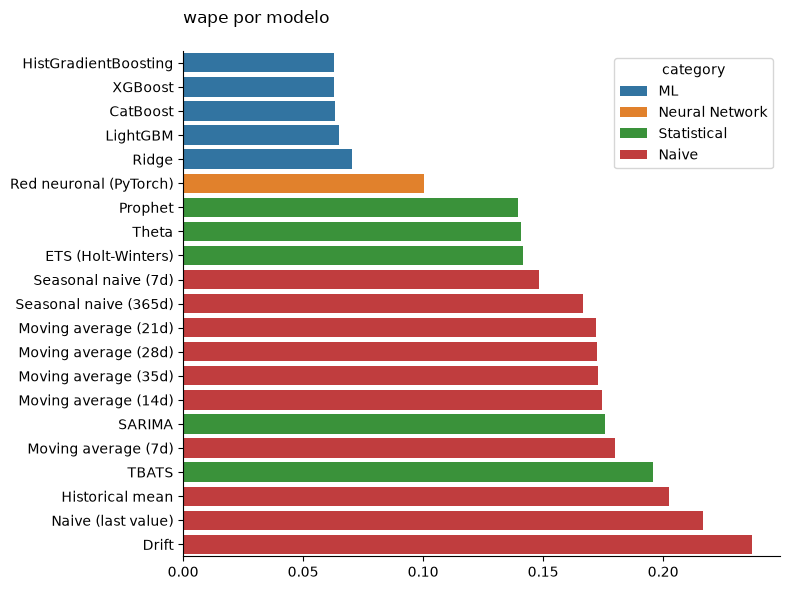

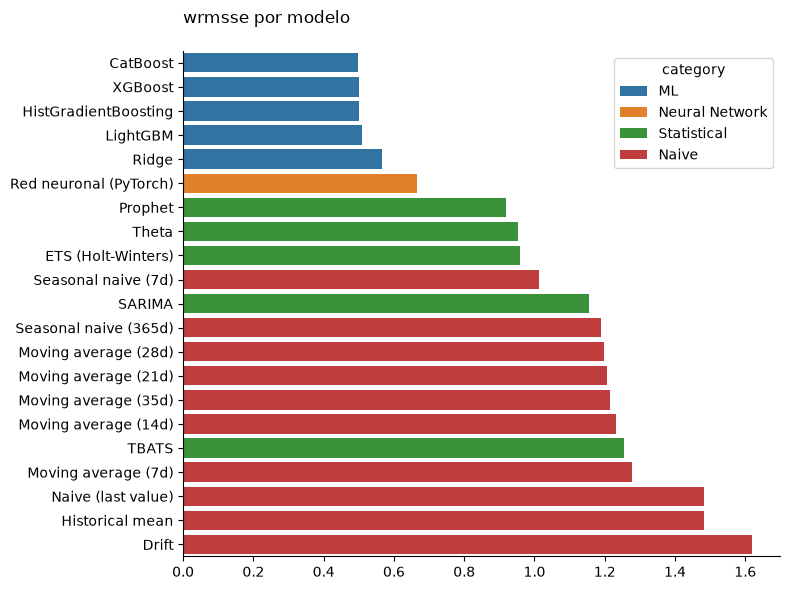

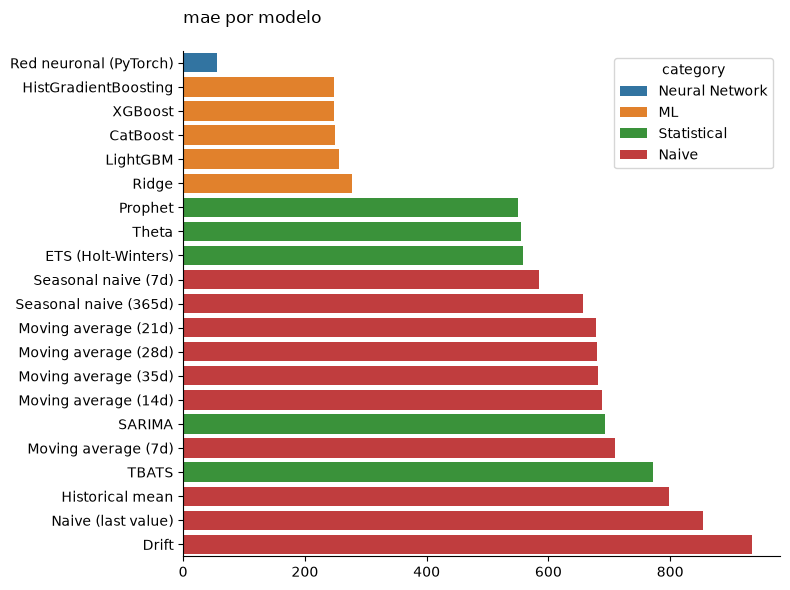

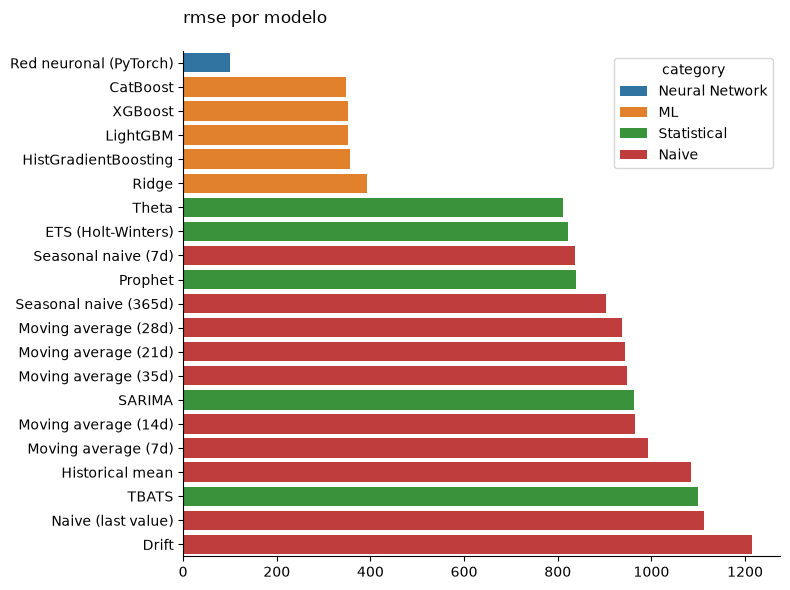

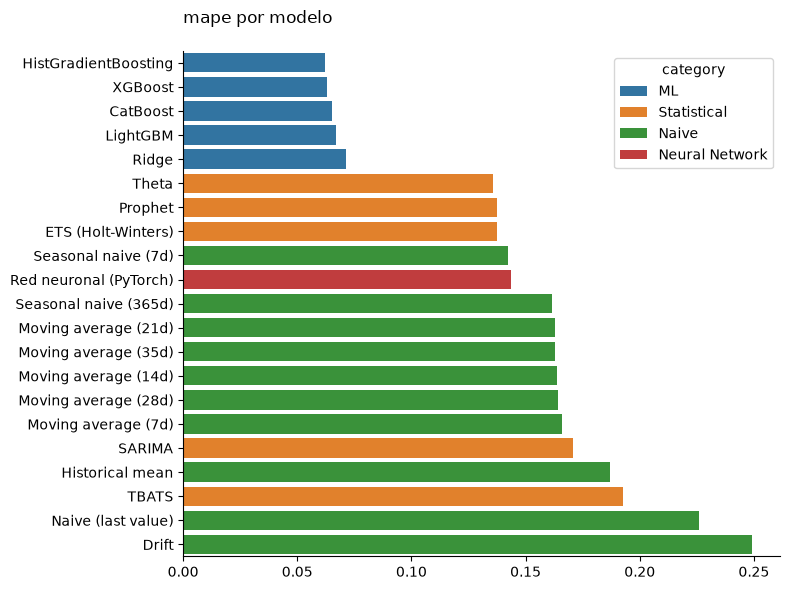

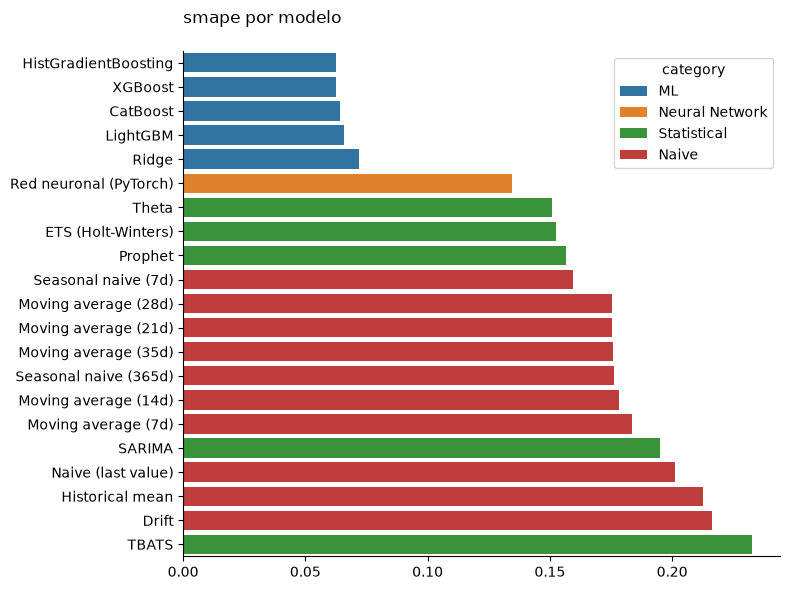

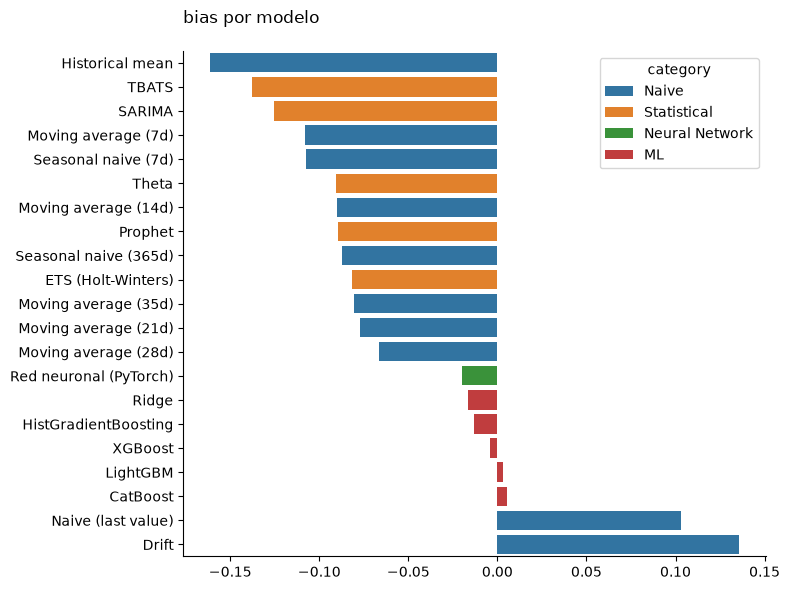

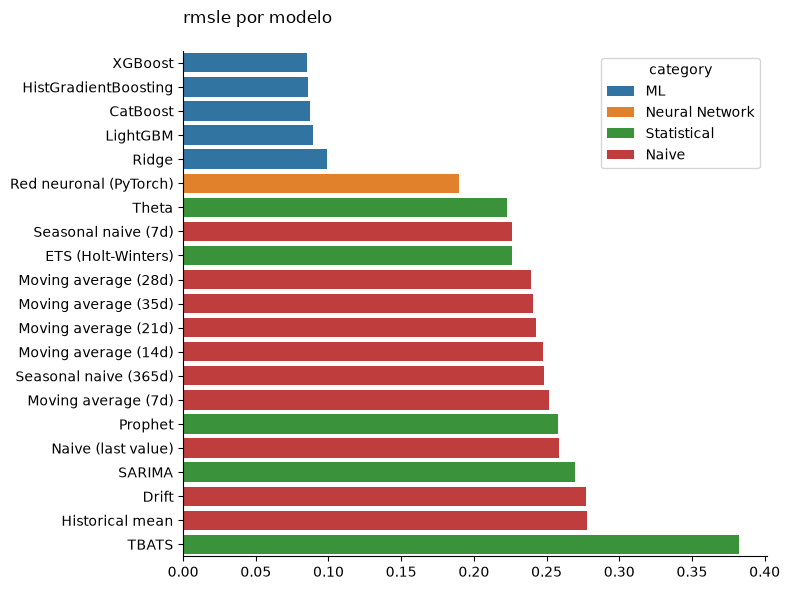

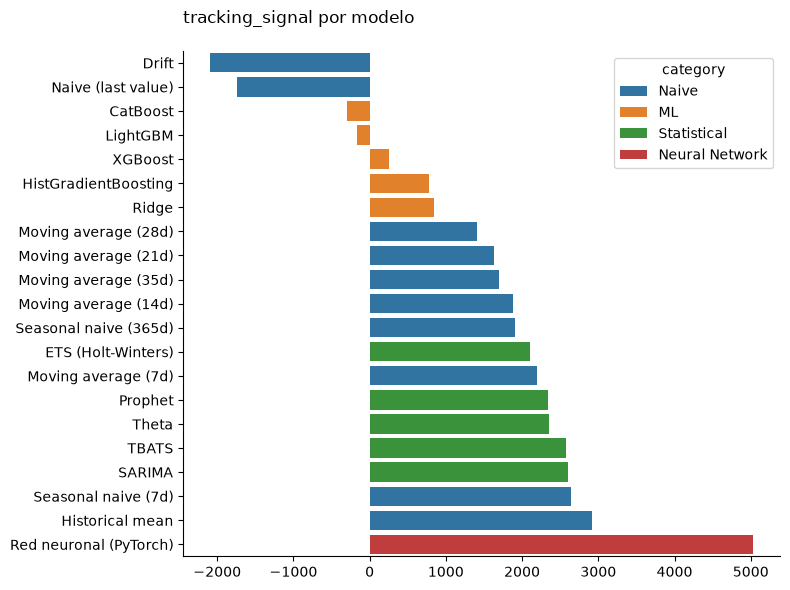

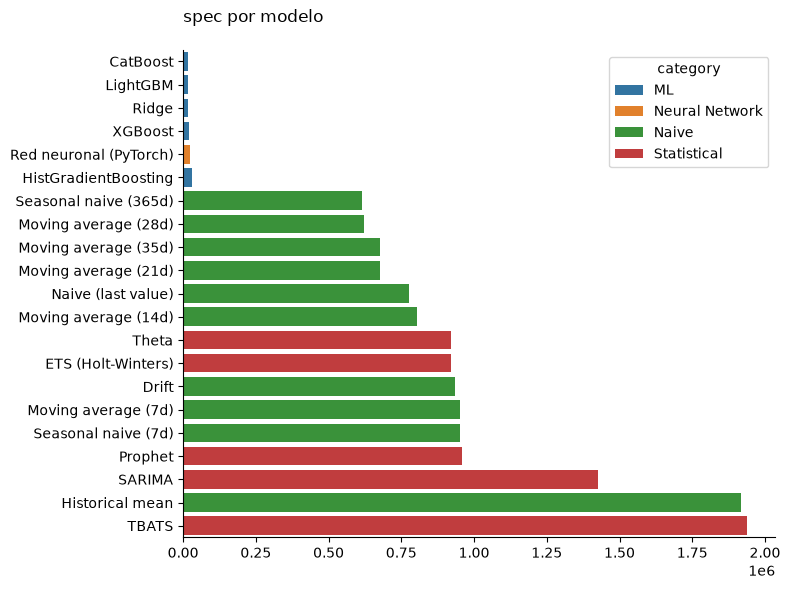

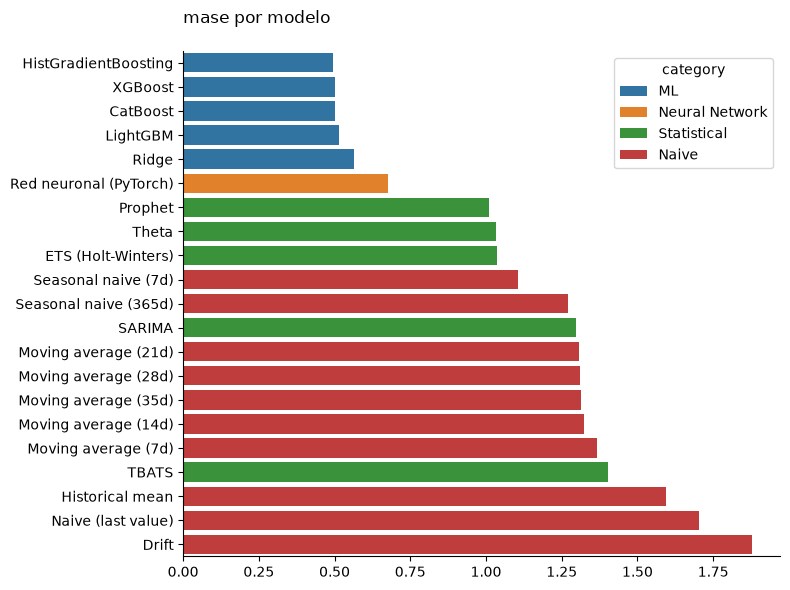

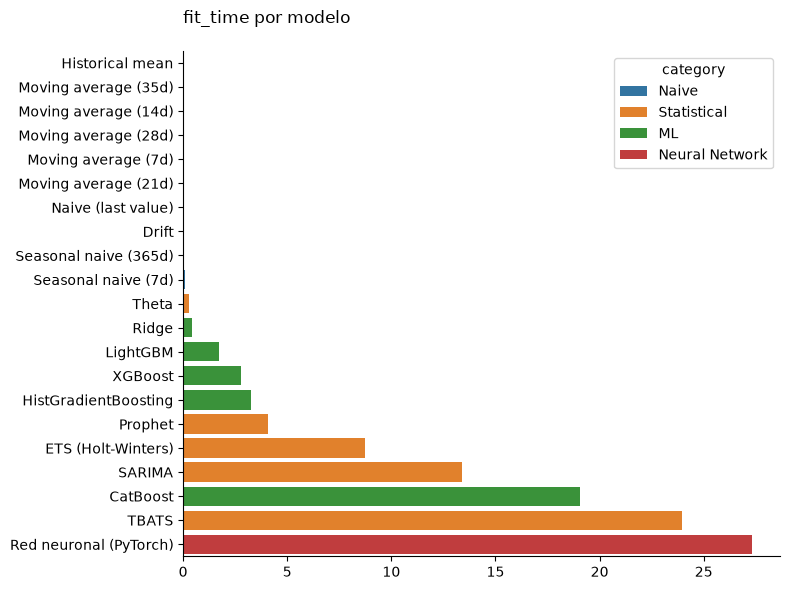

In [32]:
for col in ['wape', 'wrmsse', 'mae', 'rmse', 'mape', 'smape', 'bias', 'rmsle', 'tracking_signal', 'spec', 'mase', 'fit_time']:
    plot_barh_by_model(results_df, hue="category", x=col, y="model", title=f"{col} por modelo")

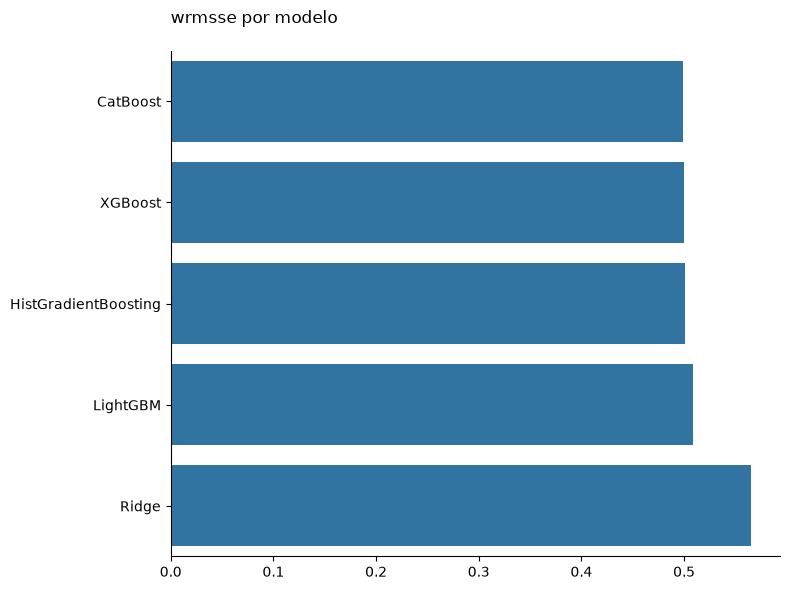

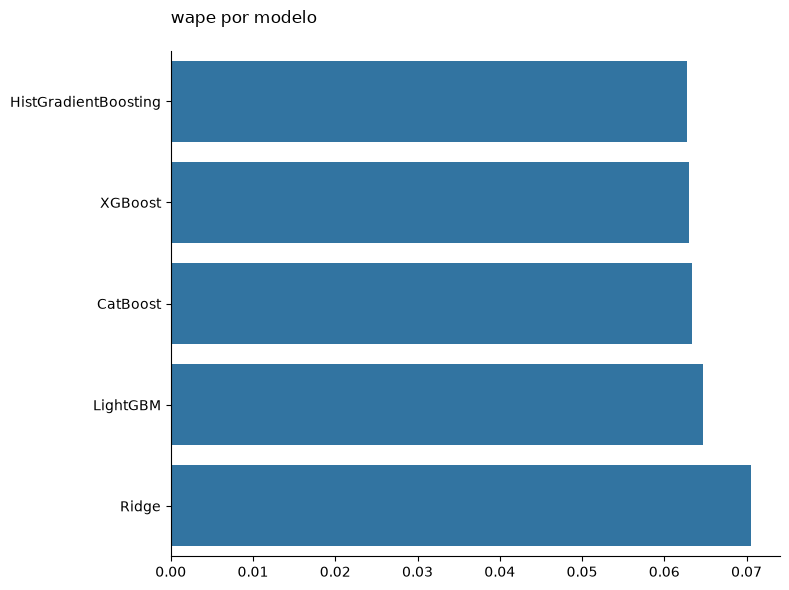

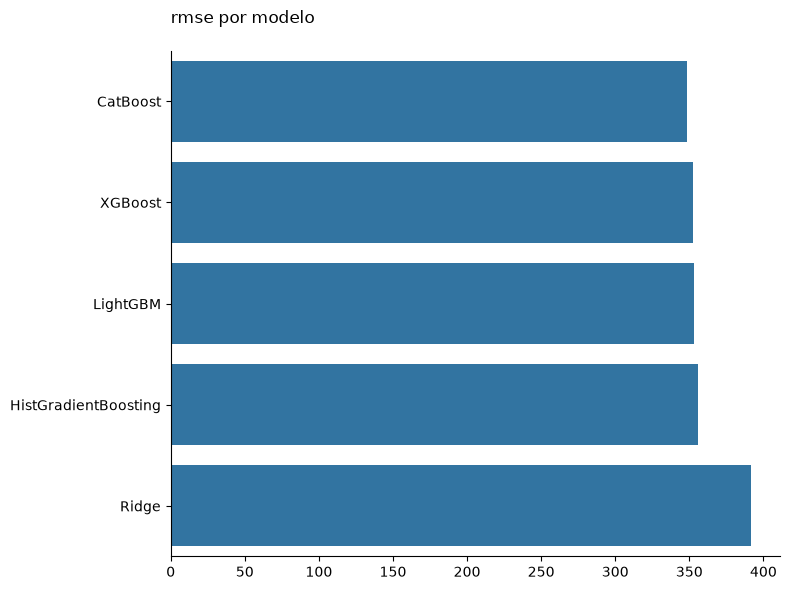

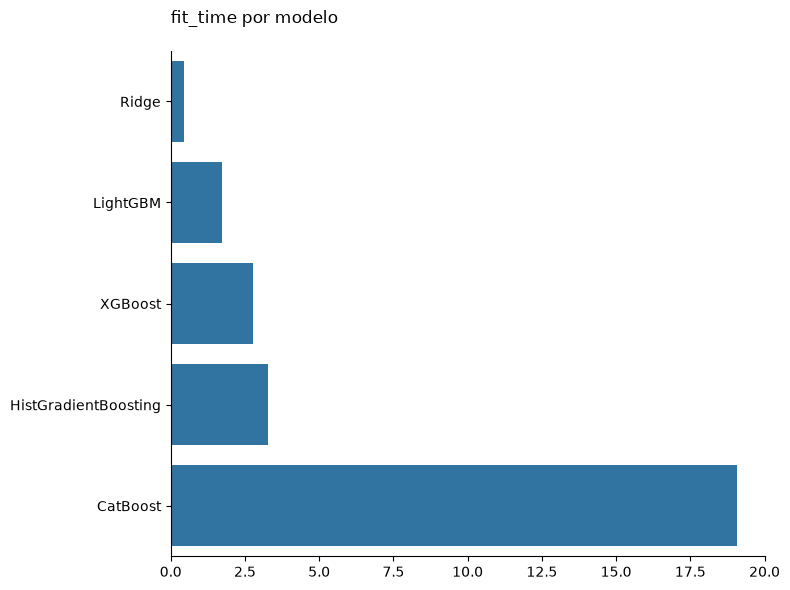

In [33]:
for col in ['wrmsse','wape','rmse', 'fit_time']:
    plot_barh_by_model(results_df.query('category == "ML"'), x=col, y="model", title=f"{col} por modelo")

# Selección de features

El resto del notebook usa LightGBM (velocidad, soporte nativo de categóricas, compatible con SHAP), así que la selección se hace sobre `lgbm_model`. Se comparan dos criterios de importancia (gain del árbol vs. permutation importance sobre validación) y luego se aplica una eliminación hacia atrás (backward elimination): se van descartando las features menos importantes mientras el WRMSSE de validación no empeore más allá de una tolerancia.

## Importancia por ganancia (gain)

In [34]:
importance_gain = (
    pd.Series(lgbm_model.booster_.feature_importance(importance_type="gain"), index=FEATURES)
    .sort_values(ascending=False)
)
importance_gain.head(20)

lag28                      8.020989e+10
lag7                       2.128442e+10
lag1                       7.223575e+09
lag91                      5.474808e+09
lag21                      2.988825e+09
lag182                     2.136687e+09
lag364                     1.850008e+09
snap                       1.694341e+09
lag14                      1.344578e+09
dayofweek                  8.089386e+08
day                        7.042113e+08
price_change               6.491839e+08
event_name_1               6.410730e+08
lag35                      5.661631e+08
price_vs_max               5.579189e+08
store_id                   5.282492e+08
price_vs_mean              4.431095e+08
lag56                      3.770208e+08
days_since_thanksgiving    3.207626e+08
is_store_closed            2.989677e+08
dtype: float64

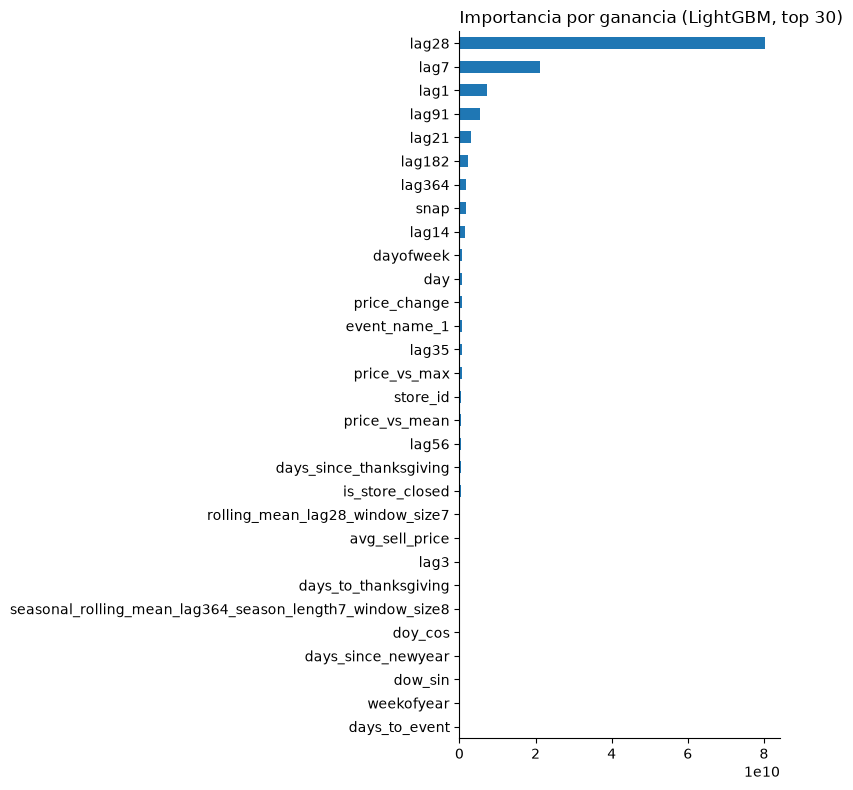

In [35]:
fig, ax = plt.subplots(figsize=(8, 8))
importance_gain.head(30).sort_values().plot.barh(ax=ax)
ax.set_title("Importancia por ganancia (LightGBM, top 30)", loc="left")
sns.despine()
plt.tight_layout()
plt.show()

## Permutation importance

El gain puede sobreestimar features de alta cardinalidad o muy usadas para splits sin aportar demasiado al error final. La permutation importance mide directamente cuánto empeora el WAPE en validación al mezclar (shuffle) cada columna, así que es un criterio más fiel al desempeño real del modelo.

In [36]:
from src.modeling import compute_permutation_importance

importance_perm = compute_permutation_importance(
    lgbm_model, X_valid, y_valid, FEATURES,
    sample_size=15_000, n_repeats=10, random_state=RANDOM_STATE,
)
importance_perm.head(20)

lag28                      248.564588
lag7                       110.519300
lag1                       104.135285
snap                        67.017641
event_name_1                32.268484
dayofweek                   31.259441
lag364                      29.332375
lag21                       20.462781
lag91                       17.494553
store_id                    17.436301
lag14                       11.919523
day                         11.577934
lag182                       7.693601
is_store_closed              7.493965
days_since_thanksgiving      6.511752
price_vs_max                 6.338247
price_change                 6.079386
days_to_event                4.732051
days_to_thanksgiving         4.540193
dow_sin                      3.872679
dtype: float64

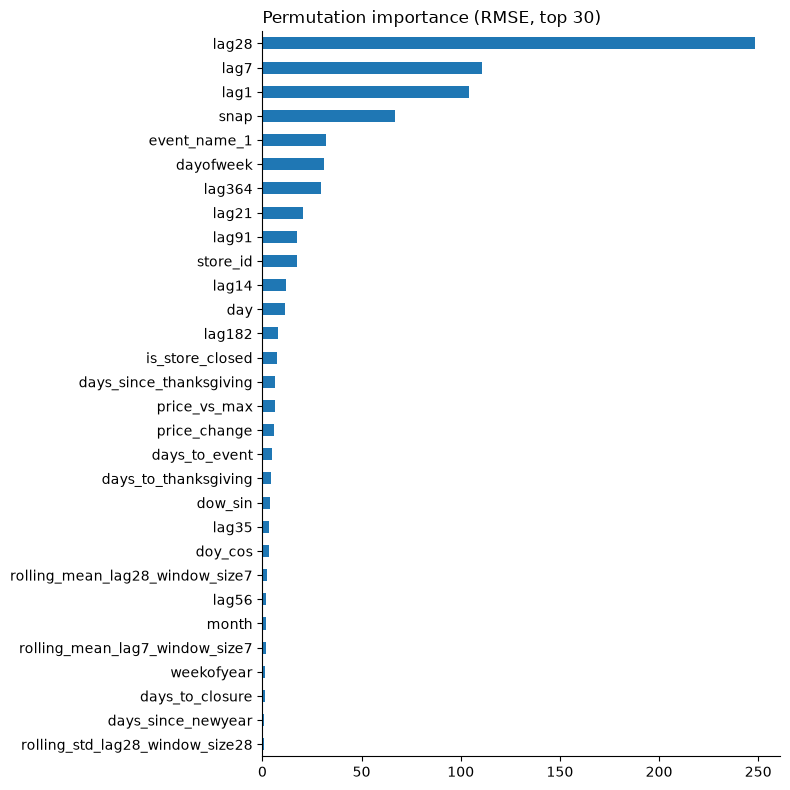

In [37]:
fig, ax = plt.subplots(figsize=(8, 8))
importance_perm.head(30).sort_values().plot.barh(ax=ax)
ax.set_title("Permutation importance (RMSE, top 30)", loc="left")
sns.despine()
plt.tight_layout()
plt.show()

## Eliminación hacia atrás (backward elimination)

Se parte del ranking de permutation importance (de menor a mayor) y se intenta eliminar cada feature: si reentrenar sin ella no empeora el WRMSSE de validación más allá de `TOLERANCE`, se descarta definitivamente.

In [38]:
from src.modeling import backward_feature_selection

selected_features, final_wrmsse, log_df = backward_feature_selection(
    X_train, y_train, X_valid, train, valid,
    FEATURES, CATEGORICAL_FEATURES, importance_perm,
    tolerance=0.001, random_state=RANDOM_STATE,
)

2026-08-23 10:53:45.332 | INFO     | src.modeling.feature_selection:backward_feature_selection:80 - Baseline (104 features): WRMSSE=0.5091
2026-08-23 10:53:46.451 | WARNING  | src.modeling.feature_selection:backward_feature_selection:96 - ELIMINADA: 'days_to_newyear' -> 103 features | WRMSSE=0.4983
2026-08-23 10:53:47.746 | SUCCESS  | src.modeling.feature_selection:backward_feature_selection:98 - mantiene: 'rolling_max_lag28_window_size28' | WRMSSE empeoraría a 0.4994
2026-08-23 10:53:48.840 | WARNING  | src.modeling.feature_selection:backward_feature_selection:96 - ELIMINADA: 'rolling_std_lag28_window_size7' -> 102 features | WRMSSE=0.4949
2026-08-23 10:53:49.985 | WARNING  | src.modeling.feature_selection:backward_feature_selection:96 - ELIMINADA: 'rolling_std_lag364_window_size91' -> 101 features | WRMSSE=0.4956
2026-08-23 10:53:51.058 | SUCCESS  | src.modeling.feature_selection:backward_feature_selection:98 - mantiene: 'rolling_std_lag91_window_size28' | WRMSSE empeoraría a 0.4994


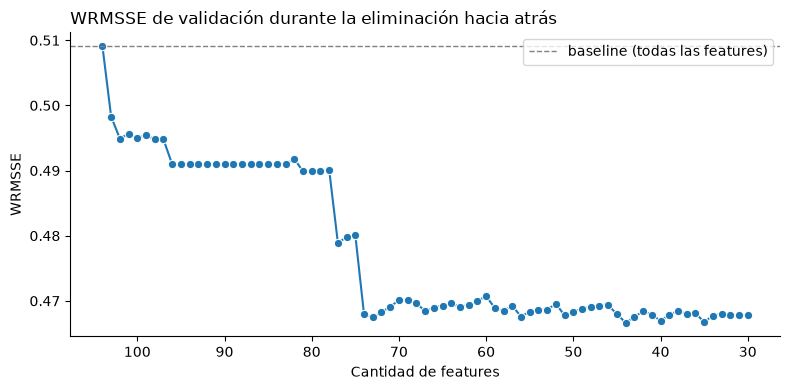

In [39]:
baseline_wrmsse = log_df.loc[log_df["removed"].isna(), "wrmsse"].iloc[0]

# Trayectoria real: baseline + solo las eliminaciones aceptadas, en orden
trajectory = log_df[log_df["accepted"]].sort_values("n_features", ascending=False)
baseline_wrmsse = trajectory["wrmsse"].iloc[0]

fig, ax = plt.subplots(figsize=(8, 4))
sns.lineplot(trajectory, x="n_features", y="wrmsse", marker="o", ax=ax)
ax.invert_xaxis()
ax.axhline(baseline_wrmsse, color="grey", linestyle="--", linewidth=1, label="baseline (todas las features)")
ax.set_title("WRMSSE de validación durante la eliminación hacia atrás", loc="left")
ax.set_xlabel("Cantidad de features")
ax.set_ylabel("WRMSSE")
ax.legend(loc="upper right")
sns.despine()
plt.tight_layout()
plt.show()

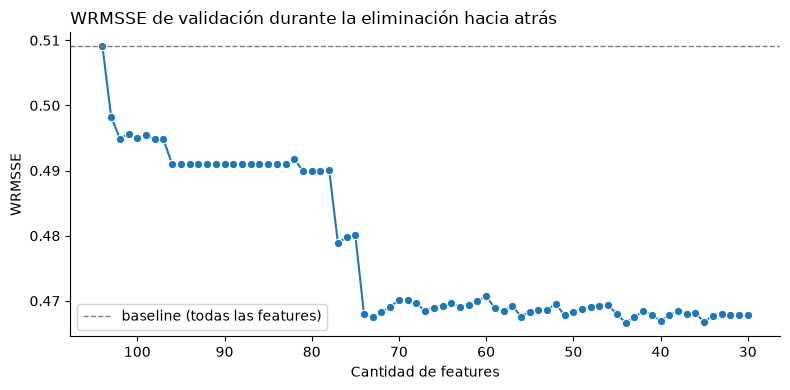

In [40]:
baseline_wrmsse = log_df.loc[log_df["removed"].isna(), "wrmsse"].iloc[0]

# Trayectoria real: baseline + solo las eliminaciones aceptadas, en orden
trajectory = log_df[log_df["accepted"]].sort_values("n_features", ascending=False)
baseline_wrmsse = trajectory["wrmsse"].iloc[0]

fig, ax = plt.subplots(figsize=(8, 4))
sns.lineplot(trajectory, x="n_features", y="wrmsse", marker="o", ax=ax)
ax.invert_xaxis()
ax.axhline(baseline_wrmsse, color="grey", linestyle="--", linewidth=1, label="baseline (todas las features)")
ax.set_title("WRMSSE de validación durante la eliminación hacia atrás", loc="left")
ax.set_xlabel("Cantidad de features")
ax.set_ylabel("WRMSSE")
ax.legend()
sns.despine()
plt.tight_layout()
plt.show()

## Features seleccionadas

Se fija `FEATURES` (y las variables derivadas `X_train`/`X_valid`/`X_test`/`CATEGORICAL_FEATURES`/`NUMERICAL_FEATURES`) al subconjunto seleccionado, para que el resto del notebook (modelo simple, SHAP, tuning con Optuna, modelo final) entrene sobre las features filtradas.

In [41]:
print(f"Features descartadas ({len(FEATURES) - len(selected_features)}): "
      f"{sorted(set(FEATURES) - set(selected_features))}")

FEATURES = selected_features
CATEGORICAL_FEATURES = [c for c in CATEGORICAL_FEATURES if c in FEATURES]
NUMERICAL_FEATURES = [c for c in NUMERICAL_FEATURES if c in FEATURES]

X_train = X_train[FEATURES]
X_valid = X_valid[FEATURES]
X_test = X_test[FEATURES]

print(f"Features finales: {len(FEATURES)} ({len(CATEGORICAL_FEATURES)} categóricas)")

Features descartadas (74): ['adi_expanding', 'avg_sell_price', 'cat_id', 'cv2_90', 'days_since_event', 'days_to_newyear', 'days_to_thanksgiving', 'dept_id', 'dow_cos', 'dow_sin', 'doy_sin', 'event_name_2', 'event_type_1', 'event_type_1_enc', 'event_type_2', 'event_type_2_enc', 'has_event', 'has_event_2', 'is_likely_stockout', 'is_month_end', 'is_month_start', 'is_store_closed', 'is_weekend', 'item_id', 'lag182', 'lag2', 'lag28', 'lag3', 'lag42', 'lag91', 'month', 'month_cos', 'month_sin', 'pct_zero_28', 'pct_zero_90', 'price_lag_7', 'price_volatility', 'price_vs_max', 'quarter', 'rolling_max_lag28_window_size28', 'rolling_max_lag28_window_size7', 'rolling_max_lag28_window_size91', 'rolling_max_lag364_window_size91', 'rolling_max_lag7_window_size14', 'rolling_max_lag7_window_size7', 'rolling_max_lag91_window_size28', 'rolling_max_lag91_window_size91', 'rolling_mean_lag28_window_size28', 'rolling_mean_lag28_window_size91', 'rolling_mean_lag364_window_size28', 'rolling_mean_lag364_window_

# Modelo simple

In [42]:
from lightgbm import LGBMRegressor
import lightgbm as lgb
from src.evaluation import wape_metric, make_wrmsse_metric

wrmsse_metric = make_wrmsse_metric(train, valid)


In [43]:
model = LGBMRegressor(
    objective="rmse",
)

t0 = time.perf_counter()
model.fit(
    X_train,
    y_train,
    eval_set=[(X_valid, y_valid)],
    eval_metric=[wrmsse_metric,],
    callbacks=[
        lgb.early_stopping(100, first_metric_only=True),
        lgb.log_evaluation(10),
    ],
)
fit_time = time.perf_counter() - t0

evaluate_model("LightGBM (selected features)", model.predict(X_valid), fit_time=fit_time, category="ML")

Training until validation scores don't improve for 100 rounds
[10]	valid_0's rmse: 654.071	valid_0's wrmsse: 0.875803
[20]	valid_0's rmse: 450.817	valid_0's wrmsse: 0.607678
[30]	valid_0's rmse: 393.32	valid_0's wrmsse: 0.538099
[40]	valid_0's rmse: 368.277	valid_0's wrmsse: 0.510793
[50]	valid_0's rmse: 356.187	valid_0's wrmsse: 0.497458
[60]	valid_0's rmse: 350.207	valid_0's wrmsse: 0.489951
[70]	valid_0's rmse: 342.295	valid_0's wrmsse: 0.479688
[80]	valid_0's rmse: 337.62	valid_0's wrmsse: 0.474003
[90]	valid_0's rmse: 334.428	valid_0's wrmsse: 0.470071


2026-08-23 10:59:29.221 | INFO     | src.evaluation.metrics:evaluate_predictions:326 - LightGBM (selected features) [ML] | WAPE: 5.85% | WRMSSE: 0.4678 | MAE: 230.608 | RMSE: 329.714 | MAPE: 5.89% | SMAPE: 5.88% | Bias: -1.02% | RMSLE: 0.0812 | TS: 634.98 | SPEC: 16645.003 | MASE: 0.4634 | fit: 4.63s


[100]	valid_0's rmse: 332.189	valid_0's wrmsse: 0.467819
Did not meet early stopping. Best iteration is:
[100]	valid_0's rmse: 332.189	valid_0's wrmsse: 0.467819
Evaluated only: rmse


{'model': 'LightGBM (selected features)',
 'category': 'ML',
 'wape': 0.05849696176142601,
 'wrmsse': 0.46781911321346226,
 'mae': 230.6081009404721,
 'rmse': 329.71389384281946,
 'mape': 0.058885948386584994,
 'smape': 0.05877602564421704,
 'bias': -0.010176551585843073,
 'rmsle': 0.08122815444201358,
 'tracking_signal': 634.980213841139,
 'spec': 16645.00289071331,
 'mase': 0.4634339254954816,
 'fit_time': 4.632596590999128}

## Explicación modelo

In [44]:
import shap

explainer = shap.TreeExplainer(model)

X_shap = X_test.sample(n=min(2000, len(X_test)), random_state=42)
shap_values = explainer.shap_values(X_shap)

In [45]:
shap_df = pd.DataFrame(shap_values, columns=X_shap.columns, index=X_shap.index)

importance_df = pd.DataFrame({
    "feature": X_shap.columns,
    "mean_abs_shap": np.abs(shap_values).mean(axis=0),
}).sort_values("mean_abs_shap", ascending=False)

print(importance_df)

                                              feature  mean_abs_shap
15                                               lag7     348.722817
14                                               lag1     238.357790
18                                              lag35     155.660173
4                                                snap     145.670545
17                                              lag21     122.984096
6                                           dayofweek     101.931529
19                                              lag56     101.797775
16                                              lag14      75.110003
3                                       price_vs_mean      73.858126
20                                             lag364      72.554634
23                    rolling_mean_lag28_window_size7      67.607511
8                                  days_since_release      45.699160
1                                        event_name_1      41.625731
0                                 

### Importancia global de features

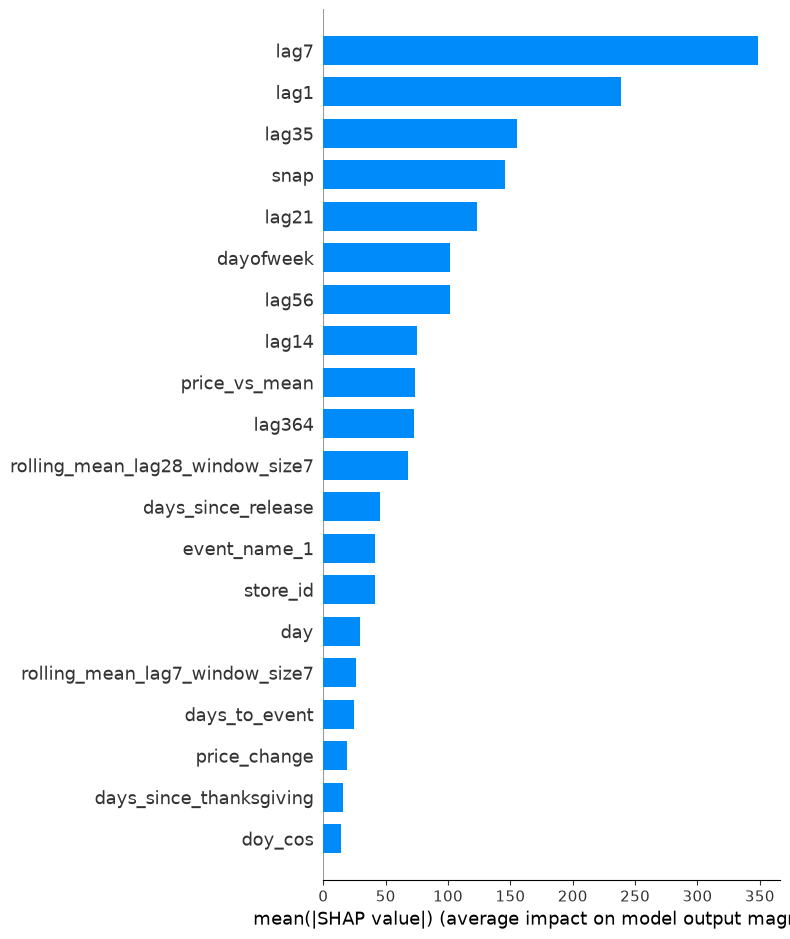

In [46]:
shap.summary_plot(shap_values, X_shap, plot_type="bar")

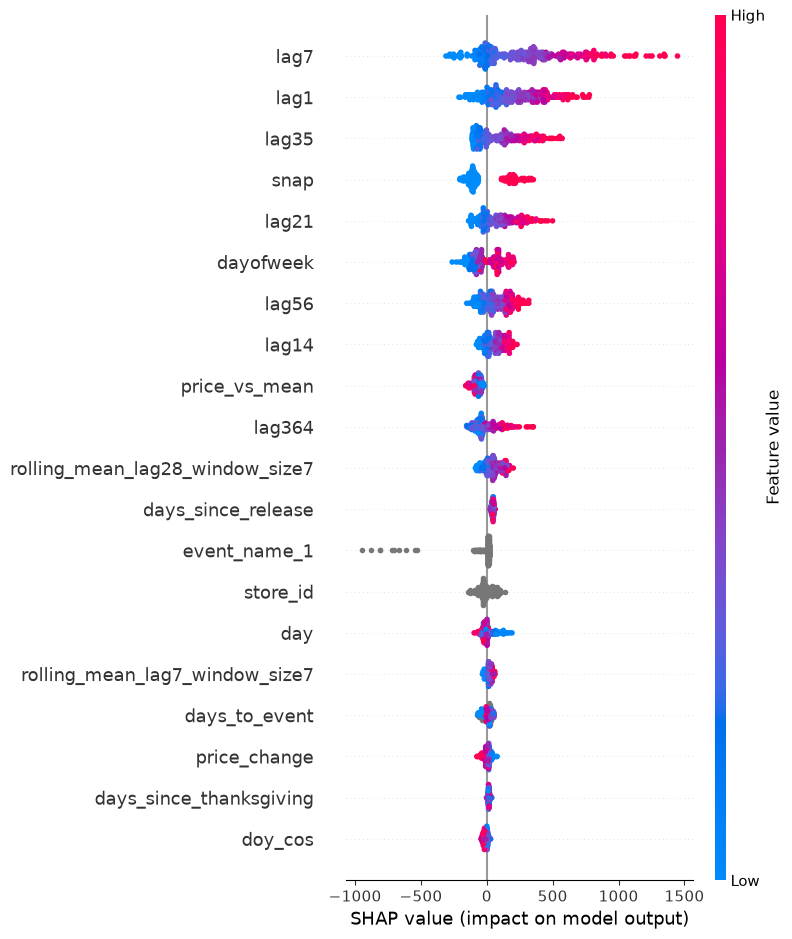

In [47]:
shap.summary_plot(shap_values, X_shap)

### Dependencia por feature

Feature más importante: lag7


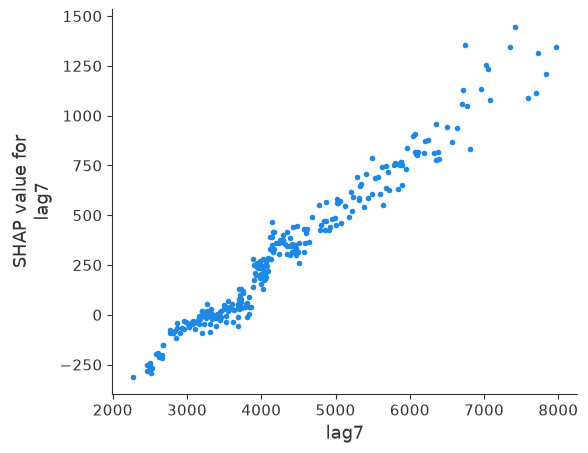

In [48]:
top_feature = X_shap.columns[np.argsort(-np.abs(shap_values).mean(axis=0))[0]]
print(f"Feature más importante: {top_feature}")

shap.dependence_plot(top_feature, shap_values, X_shap, interaction_index=None)

# Predicciones

In [49]:
from src.evaluation import explain_prediction


In [50]:
from src.evaluation import plot_forecast


In [51]:
from src.evaluation import analizar_prediccion as _analizar_prediccion

def analizar_prediccion(agg_id, date=None, max_display=10):
    return _analizar_prediccion(
        test, X_test, df_pred, TARGET, agg_id,
        date=date, max_display=max_display, explainer=explainer,
    )


In [52]:
from src.evaluation.metrics import build_predictions_report

metrics_test, df_pred = build_predictions_report(train, test, y_test, model.predict(X_test), target_col=TARGET)

print(f"Test WAPE: {metrics_test['wape']:.2%}")
print(f"Test WRMSSE: {metrics_test['wrmsse']:.4f}")

Test WAPE: 6.42%
Test WRMSSE: 0.5382


In [53]:
#from src.evaluation.metrics import build_series_metrics

#df_metrics = build_series_metrics(train, df_pred, target_col=TARGET, weight_level=["date"])
#df_metrics.head(10)

In [54]:
#df_pred.query('agg_id == "FOODS_3_FOODS_CA_3_CA"').nlargest(10, 'wape')

In [55]:
#_analizar_prediccion('TOTAL', '2016-05-16',)

# Modelo optimizado

In [56]:
import optuna
from optuna.integration import LightGBMPruningCallback
import lightgbm as lgb
import numpy as np

In [57]:
import lightgbm as lgb
import numpy as np
import optuna
from optuna.integration import LightGBMPruningCallback

In [58]:
def objective(trial):
    model = lgb.LGBMRegressor(
        objective="rmse",
        learning_rate=trial.suggest_float("learning_rate", 0.03, 0.15, log=True),
        n_estimators=1500,
        num_leaves=trial.suggest_int("num_leaves", 31, 255),
        max_depth=trial.suggest_int("max_depth", 5, 10),
        min_child_samples=trial.suggest_int("min_child_samples", 20, 200),
        subsample=trial.suggest_float("subsample", 0.6, 1.0),
        subsample_freq=1,
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.6, 1.0),
        reg_alpha=trial.suggest_float("reg_alpha", 1e-3, 5, log=True),
        reg_lambda=trial.suggest_float("reg_lambda", 1e-3, 5, log=True),
        random_state=42,
        n_jobs=-1,
        verbosity=-1,
    )
    model.fit(
        X_train,
        y_train,
        eval_set=[(X_valid, y_valid)],
        eval_metric="rmse",
        categorical_feature=CATEGORICAL_FEATURES,
        callbacks=[
            lgb.early_stopping(30, first_metric_only=True, verbose=False),
            LightGBMPruningCallback(trial, "rmse"),
        ],
    )
    y_pred = model.predict(X_valid, num_iteration=model.best_iteration_)
    _, final_wrmsse, _ = wrmsse_metric(y_valid, y_pred)
    return final_wrmsse

In [ ]:
study = optuna.create_study(
    study_name=f"study_{LEVEL}", 
    direction="minimize",
    storage="sqlite:///../artifacts/optuna_study.db",
    load_if_exists=True,
    sampler=optuna.samplers.TPESampler(
        seed=42,
    ),
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=10, n_startup_trials=5),
)

study.optimize(
    objective,
    n_trials=1_000,
    timeout=60 * 15,
    show_progress_bar=True,
)

best_trial = study.best_trial
print(f"Mejor WRMSSE: {best_trial.value:.4f}")
print("Mejores hiperparámetros:", best_trial.params)

[I 2026-08-23 10:59:34,253] A new study created in RDB with name: study_level_06_daily_store


  0%|          | 0/1000 [00:00<?, ?it/s]

[I 2026-08-23 11:00:29,087] Trial 0 finished with value: 0.46990812716048247 and parameters: {'learning_rate': 0.054816785328198704, 'num_leaves': 244, 'max_depth': 9, 'min_child_samples': 128, 'subsample': 0.6624074561769746, 'colsample_bytree': 0.662397808134481, 'reg_alpha': 0.0016400214911202306, 'reg_lambda': 1.599409170128044}. Best is trial 0 with value: 0.46990812716048247.
[I 2026-08-23 11:01:06,089] Trial 1 finished with value: 0.47847767537657343 and parameters: {'learning_rate': 0.07893736353172352, 'num_leaves': 190, 'max_depth': 5, 'min_child_samples': 195, 'subsample': 0.9329770563201687, 'colsample_bytree': 0.6849356442713105, 'reg_alpha': 0.004705059281907645, 'reg_lambda': 0.004768785415482609}. Best is trial 0 with value: 0.46990812716048247.
[I 2026-08-23 11:02:27,537] Trial 2 finished with value: 0.4733543830498 and parameters: {'learning_rate': 0.048952790869270256, 'num_leaves': 149, 'max_depth': 7, 'min_child_samples': 72, 'subsample': 0.8447411578889518, 'colsa

# Modelo final

In [ ]:
model_params = best_trial.params

final_model = lgb.LGBMRegressor(
    objective="rmse",
    n_estimators=1_500,
    random_state=42,
    n_jobs=-1,
    verbosity=-1,
    subsample_freq=1,
    **model_params,
)

t0 = time.perf_counter()
final_model.fit(
    X_train, y_train,
    eval_set=[(X_valid, y_valid)],
    eval_metric=wrmsse_metric,
    categorical_feature=CATEGORICAL_FEATURES,
    callbacks=[
        lgb.early_stopping(50, first_metric_only=True),
        lgb.log_evaluation(10),
    ],
)
fit_time = time.perf_counter() - t0

evaluate_model("LightGBM (selected features | Optuna)", final_model.predict(X_valid), fit_time=fit_time, category="ML")

Training until validation scores don't improve for 50 rounds
[10]	valid_0's rmse: 446.741	valid_0's wrmsse: 2.53653
[20]	valid_0's rmse: 329.169	valid_0's wrmsse: 1.89584
[30]	valid_0's rmse: 247.765	valid_0's wrmsse: 1.45333
[40]	valid_0's rmse: 192.975	valid_0's wrmsse: 1.1561
[50]	valid_0's rmse: 157.468	valid_0's wrmsse: 0.959771
[60]	valid_0's rmse: 134.476	valid_0's wrmsse: 0.832184
[70]	valid_0's rmse: 120.619	valid_0's wrmsse: 0.752157
[80]	valid_0's rmse: 111.924	valid_0's wrmsse: 0.701868
[90]	valid_0's rmse: 106.511	valid_0's wrmsse: 0.669201
[100]	valid_0's rmse: 103.03	valid_0's wrmsse: 0.649267
[110]	valid_0's rmse: 100.702	valid_0's wrmsse: 0.637029
[120]	valid_0's rmse: 98.6499	valid_0's wrmsse: 0.626425
[130]	valid_0's rmse: 97.0027	valid_0's wrmsse: 0.618637
[140]	valid_0's rmse: 95.8368	valid_0's wrmsse: 0.613823
[150]	valid_0's rmse: 95.0652	valid_0's wrmsse: 0.61046
[160]	valid_0's rmse: 94.3368	valid_0's wrmsse: 0.607486
[170]	valid_0's rmse: 93.828	valid_0's wrms

2026-08-23 10:42:15.830 | INFO     | src.evaluation.metrics:evaluate_predictions:326 - LightGBM (selected features | Optuna) [ML] | WAPE: 8.84% | WRMSSE: 0.5827 | MAE: 49.773 | RMSE: 86.978 | MAPE: 14.04% | SMAPE: 12.49% | Bias: -0.07% | RMSLE: 0.1852 | TS: 202.66 | SPEC: 4517.111 | MASE: 0.5917 | fit: 432.48s


{'model': 'LightGBM (selected features | Optuna)',
 'category': 'ML',
 'wape': 0.08837945801950582,
 'wrmsse': 0.5826889032113847,
 'mae': 49.77308310997259,
 'rmse': 86.97830524931737,
 'mape': 0.14039006798658074,
 'smape': 0.12493459783779293,
 'bias': -0.0007010003827051474,
 'rmsle': 0.18520847677946115,
 'tracking_signal': 202.65523436637912,
 'spec': 4517.110545296331,
 'mase': 0.5917382491805723,
 'fit_time': 432.47892146999993}

## Resultados finales

In [ ]:
results_df = pd.DataFrame(model_results).sort_values("wrmsse").query('wape <= 0.15')
results_df

,model,category,wape,wrmsse,mae,rmse,mape,smape,bias,rmsle,tracking_signal,spec,mase,fit_time
22,LightGBM (selected features | Optuna),ML,0.088379,0.582689,49.773083,86.978305,0.140390,0.124935,-0.000701,0.185208,202.655234,4517.110545,0.591738,432.478921
21,LightGBM (selected features),ML,0.091476,0.605749,51.517198,88.226265,0.141677,0.131270,-0.007856,0.197048,2194.174316,3356.892023,0.617523,20.066491
16,XGBoost,ML,0.092615,0.612505,52.158519,90.430386,0.141738,0.129003,-0.001691,0.188974,466.394975,3959.035213,0.624418,4.455997
18,HistGradientBoosting,ML,0.096821,0.644081,54.527418,97.586194,0.138676,0.129569,-0.014509,0.187520,3828.660092,5952.123200,0.650278,6.360755
15,LightGBM,ML,0.100180,0.647779,56.418605,98.055422,0.151103,0.136132,0.018173,0.205416,-4634.946620,4075.085124,0.670139,3.996300
17,CatBoost,ML,0.101598,0.651572,57.217203,102.185187,0.155435,0.140754,0.020923,0.222400,-5261.866410,5813.178936,0.670498,73.994861
20,Red neuronal (PyTorch),Neural Network,0.100282,0.664811,56.451958,101.112627,0.143616,0.134509,-0.019733,0.189865,5027.640505,24816.267371,0.677905,27.297045
19,Ridge,ML,0.111466,0.721619,62.775077,106.710846,0.239579,0.221503,-0.021097,0.572254,4835.779191,6218.032516,0.736770,2.553791


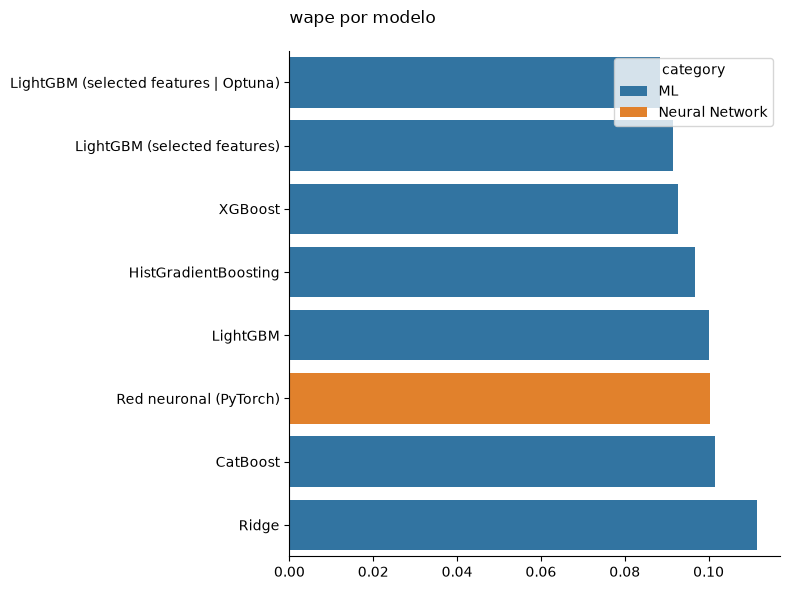

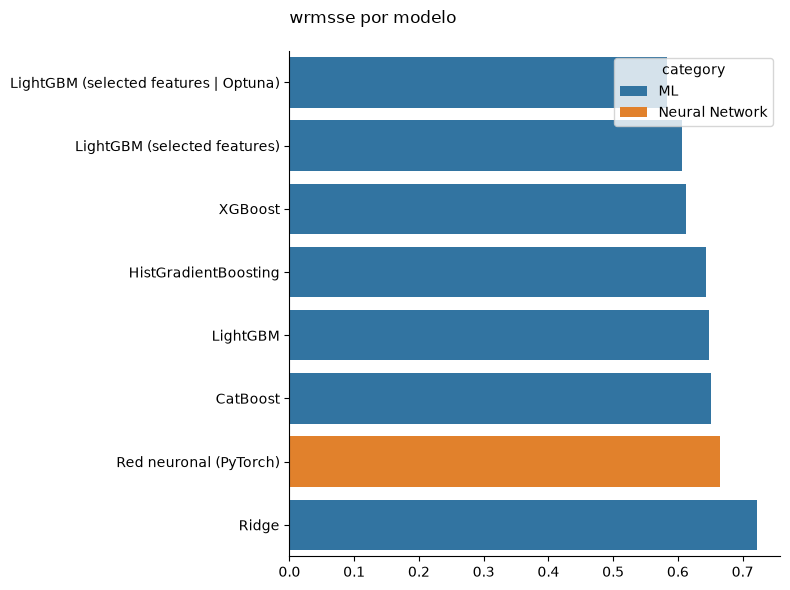

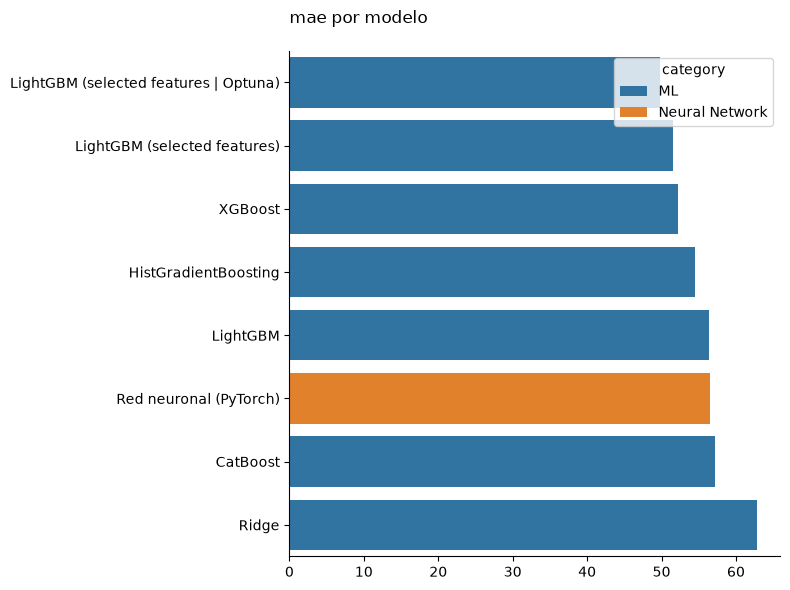

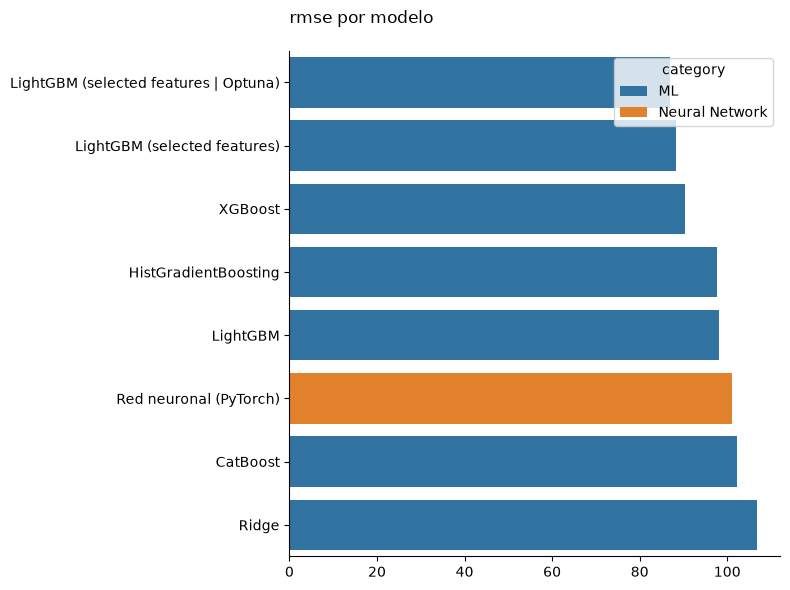

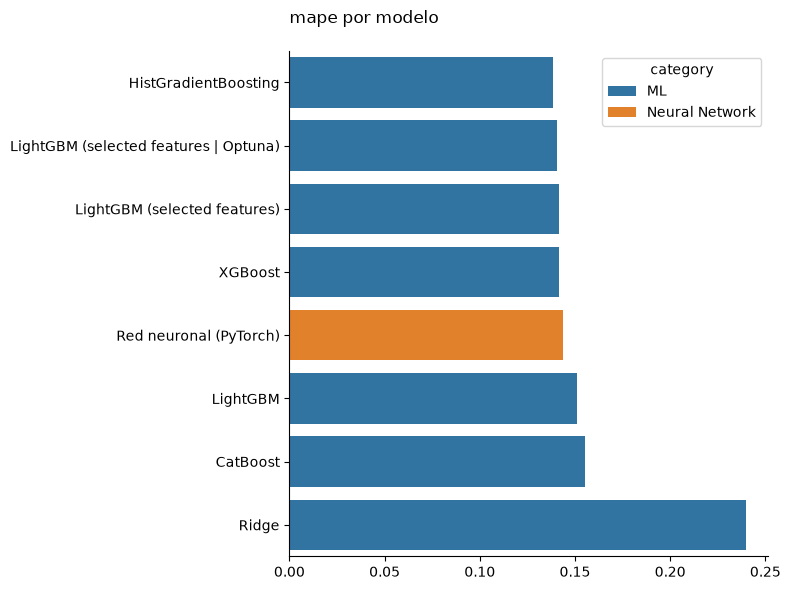

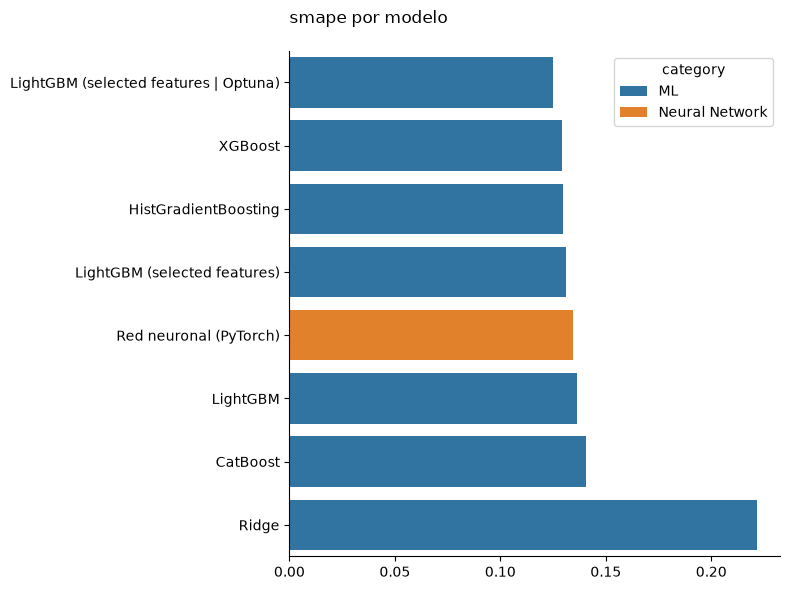

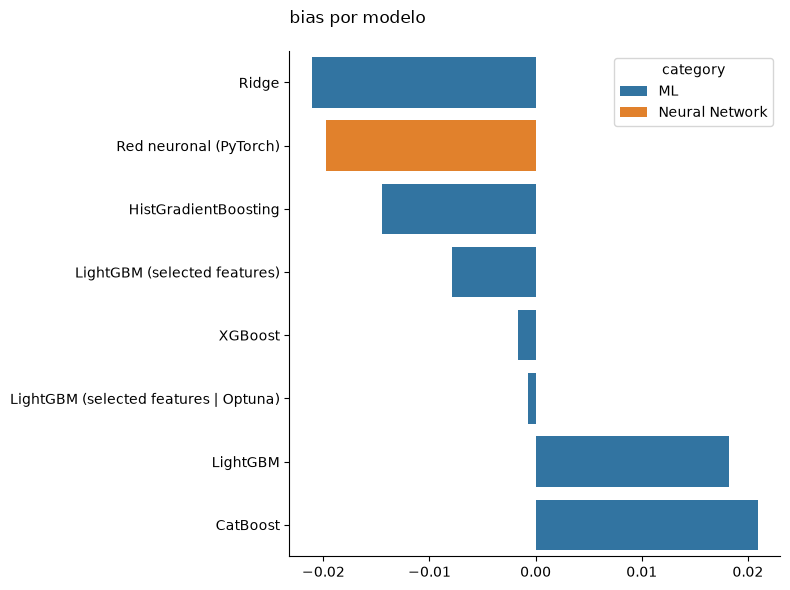

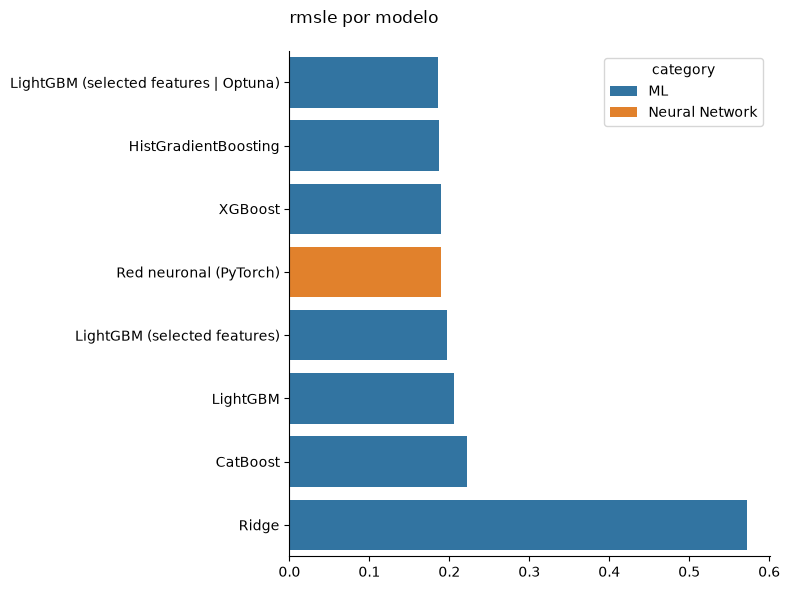

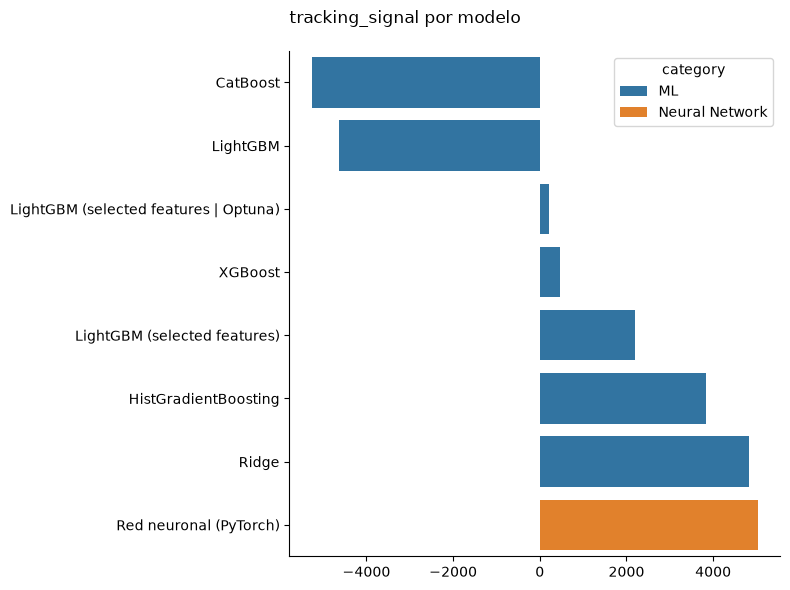

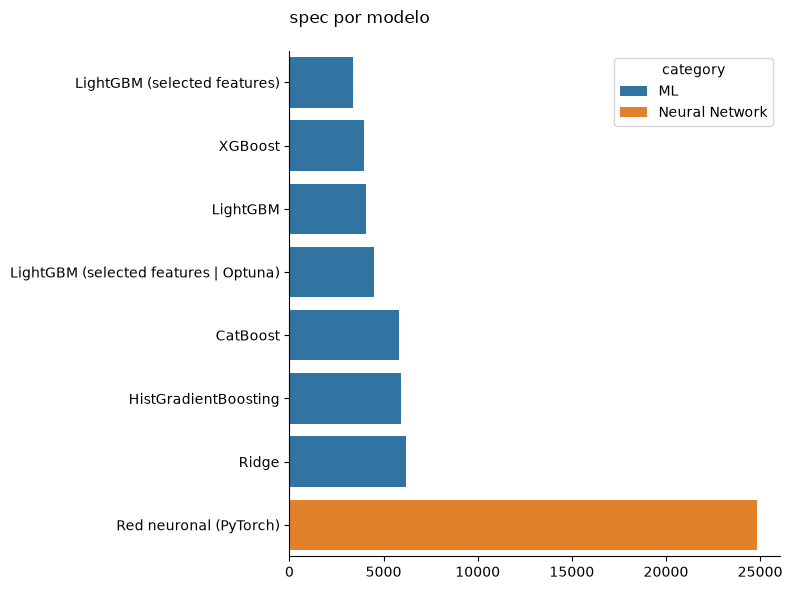

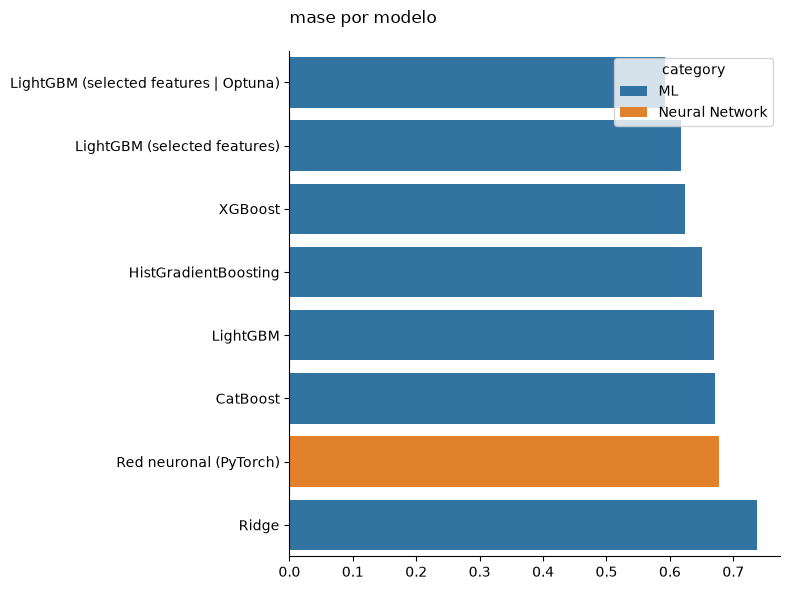

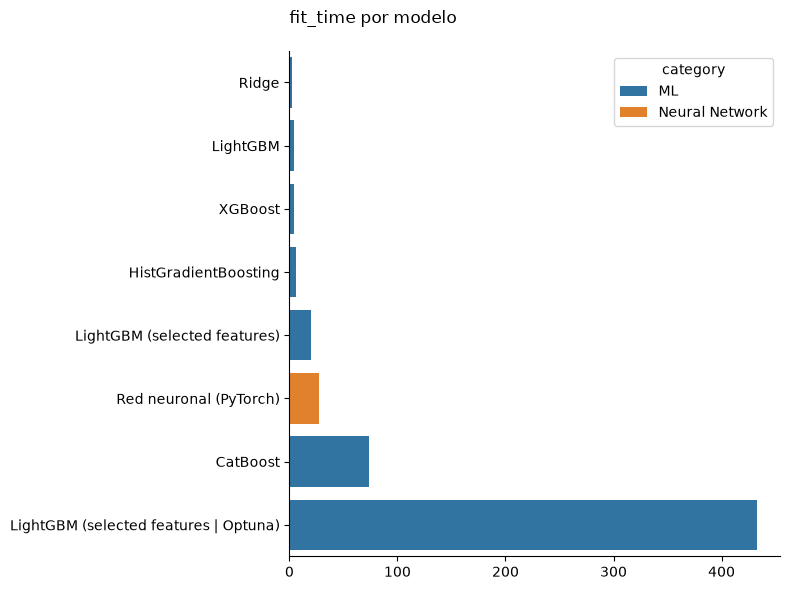

In [ ]:
for col in ['wape', 'wrmsse', 'mae', 'rmse', 'mape', 'smape', 'bias', 'rmsle', 'tracking_signal', 'spec', 'mase', 'fit_time']:
    plot_barh_by_model(results_df, hue="category", x=col, y="model", title=f"{col} por modelo")

# Exploración modelo final

In [ ]:
metrics_test_final, df_pred = build_predictions_report(train, test, y_test, final_model.predict(X_test), target_col=TARGET)

print(f"Test WAPE: {metrics_test_final['wape']:.2%}")
print(f"Test WRMSSE: {metrics_test_final['wrmsse']:.4f}")

Test WAPE: 8.68%
Test WRMSSE: 0.6159


In [ ]:
# from src.evaluation.metrics import build_series_metrics

# df_metrics = build_series_metrics(train, df_pred, target_col=TARGET, weight_level=["date"])
# df_metrics.head(10)

In [ ]:
# df_pred.query('agg_id == "FOODS_3_FOODS_CA_3_CA"').nlargest(10, 'wape')

In [ ]:
# analizar_prediccion('FOODS_3_FOODS_CA_3_CA', '2016-05-15',)

# Exportar

In [ ]:
import joblib

feature_importance = (
    pd.Series(final_model.booster_.feature_importance(importance_type="gain"), index=FEATURES)
    .sort_values(ascending=False)
)

artifact = {
    # modelo y datos de trabajo
    "level": LEVEL,
    "df": df,
    "model": final_model,
    "model_params": model_params,
    "metrics_results": results_df,
    "X_train": X_train,
    "y_train": y_train,
    "X_valid": X_valid,
    "y_valid": y_valid,
    "X_test": X_test,
    "y_test": y_test,
    "train": train,
    "valid": valid,
    "test": test,
    # features y columnas
    "features": FEATURES,
    "categorical_features": CATEGORICAL_FEATURES,
    "numerical_features": NUMERICAL_FEATURES,
    "id_cols": ID_COLS,
    "leaky_cols": LEAKY_COLS,
    "target": TARGET,
    "feature_importance": feature_importance,
    # predicciones y métricas del modelo final (test)
    #"df_pred": df_pred,
    #"df_metrics": df_metrics,
    # comparación de todos los modelos probados (validación)
    "model_results": model_results,
    "results_df": results_df,
    #"series_metrics_valid": series_metrics_df,
    # metadatos
    "wape_valid": model_results[-1]["wape"],
    "wrmsse_valid": model_results[-1]["wrmsse"],
    "wape_test": metrics_test_final["wape"],
    "wrmsse_test": metrics_test_final["wrmsse"],
    "train_start": str(first_date.date()),
    "valid_start": str(valid_start.date()),
    "test_start": str(test_start.date()),
}

artifact_path = f"../artifacts/models/{LEVEL}_{TARGET}_artifact.pkl"
joblib.dump(artifact, artifact_path)
print(f"Artifact guardado en {artifact_path}")

Artifact guardado en ../artifacts/models/level_09_daily_store_dept_sales_artifact.pkl
